<center>

**PUSAT ILMU KOMPUTER UNIVERSITAS INDONESIA**

Bootcamp Data Analytics, Artificial Intelligence, dan Big Data

Officer Development Program - Data Analytics · PT Bank Negara Indonesia (Persero) Tbk.

## **Hands-on Lab: Regression untuk Analitik Perbankan**

### **Hari 10 · Classical ML - Supervised: Linear & Polynomial Regression**

**Durasi: 2 jam (120 menit)**

</center>

---

### **Cakupan Materi**

| No | Topik | Bagian di Notebook |
|----|-------|--------------------|
| 1 | Intro to Regression | Bagian 1 |
| 2 | Linear Regression (simple & multiple) | Bagian 2 dan 3 |
| 3 | OLS vs SGD | Bagian 4 |
| 4 | Evaluating and Interpreting Regression Result | Bagian 5 |
| 5 | Multicollinearity | Bagian 6 |
| 6 | Overfitting | Bagian 7 |
| 7 | Polynomial Regression | Bagian 8 |

### **Alokasi Waktu yang Disarankan**

| Segmen | Waktu | Aktivitas |
|--------|-------|-----------|
| Persiapan | 10 menit | Pasang library, muat dataset, pastikan semua peserta siap |
| Bagian 1 - 3 | 30 menit | Intro, simple linear regression, multiple linear regression |
| Bagian 4 - 5 | 30 menit | OLS vs SGD, evaluasi dan interpretasi hasil |
| Bagian 6 - 8 | 35 menit | Multikolinearitas, overfitting, polynomial regression |
| Penutup | 15 menit | Ringkasan, tanya jawab, dan pengantar kompetisi |

### **Cara Mengikuti Sesi Ini**

1. Berkas notebook (`.ipynb`) dan dataset (`.csv`) sudah disediakan. Letakkan keduanya pada folder yang sama.
2. Jalankan setiap cell secara berurutan sambil menyimak penjelasan fasilitator. Perhatikan keluaran tiap cell, bukan hanya menekan tombol Run.
3. Notebook ini dirancang untuk **diketik ulang dan diutak-atik**, bukan sekadar dibaca. Kalau ada angka yang membuat penasaran, ubah dan jalankan lagi.
4. Di beberapa titik ada kotak **Giliran Anda**. Itu tugas singkat satu sampai dua menit untuk mengubah satu nilai lalu mengamati akibatnya. Jangan dilewat, di situlah pemahaman terbentuk.
5. Bertanya kapan saja. Materi ini bertumpuk, jadi kalau satu bagian belum jelas, bagian berikutnya akan terasa lebih berat.

Isi dengan data diri Anda supaya notebook ini mudah dikenali bila nanti Anda simpan atau bagikan kembali.

In [159]:
NAMA = ""
UNIT_KERJA = ""
ID_PESERTA = ""

print(f"Peserta   : {NAMA}")
print(f"Unit Kerja: {UNIT_KERJA}")
print(f"ID Peserta: {ID_PESERTA}")

Peserta   : 
Unit Kerja: 
ID Peserta: 


## Persiapan Lingkungan Kerja

Jalankan cell di bawah ini bila ada library yang belum terpasang. Peserta yang memakai Google Colab dapat melewati cell instalasi karena seluruh library sudah tersedia.

In [160]:
# !pip install numpy pandas matplotlib seaborn scikit-learn scipy statsmodels

### Import Libraries

In [161]:
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as scp

from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.datasets import make_regression

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Semua library berhasil dimuat.')

Semua library berhasil dimuat.


### Dataset yang Digunakan

Lab ini memakai `Bank_Nasabah_Kredit.csv`, dataset sintetis yang dirancang menyerupai data nasabah kartu kredit sebuah bank.

Berisi 900 profil nasabah. Tujuan pemodelan adalah memprediksi **limit kredit** yang layak diberikan kepada seorang nasabah berdasarkan profil finansialnya. Ini adalah kasus nyata di perbankan, yaitu *credit limit assignment*, yang biasanya masih dikerjakan dengan aturan manual dan berpotensi digantikan oleh model.

| Kolom | Deskripsi |
|-------|-----------|
| `IDNasabah` | Identifier nasabah, tidak dipakai untuk pemodelan |
| `Usia` | Usia nasabah dalam tahun |
| `JenisPekerjaan` | Karyawan, Wiraswasta, PNS, atau Profesional |
| `PendapatanBulanan_juta` | Pendapatan bulanan dalam juta rupiah |
| `PendapatanTahunan_juta` | Pendapatan tahunan dalam juta rupiah |
| `SkorKredit` | Skor kredit internal, rentang 300 sampai 850 |
| `LamaMenjadiNasabah_tahun` | Lama relasi nasabah dengan bank |
| `RataSaldoTabungan_juta` | Rata-rata saldo tabungan enam bulan terakhir |
| `JumlahProdukDimiliki` | Banyaknya produk bank yang dimiliki nasabah |
| `TotalTransaksiBulanan` | Jumlah transaksi per bulan |
| `RasioUtangTerhadapPendapatan` | Debt to income ratio, rentang 0 sampai 1 |
| `LimitKredit_juta` | **Target**, limit kredit dalam juta rupiah |

> Catatan: dataset ini dibangkitkan secara sintetis khusus untuk keperluan pelatihan sehingga tidak memuat data nasabah yang sebenarnya.

### Menyiapkan Berkas Dataset

Cell di bawah ini menuliskan `Bank_Nasabah_Kredit.csv` ke folder kerja Anda. Datanya sudah ditanam di dalam notebook, jadi **lab ini bisa langsung jalan di Google Colab tanpa mengunggah berkas apa pun**.

Isi cell ini tidak perlu Anda pahami. Cukup jalankan sekali. Kalau Anda sudah punya berkas CSV-nya di folder yang sama, cell ini tidak akan menimpanya.

In [162]:
# === PENYIAPAN DATA, jalankan sekali lalu lupakan ===
import base64, gzip, os

NAMA_BERKAS = 'Bank_Nasabah_Kredit.csv'

_DATA = '''
...
'''

if not os.path.exists(NAMA_BERKAS):
    with open(NAMA_BERKAS, 'wb') as f:
        f.write(gzip.decompress(base64.b64decode(''.join(_DATA.split()))))
    print(f'{NAMA_BERKAS} berhasil dibuat.')
else:
    print(f'{NAMA_BERKAS} sudah ada, berkas lama dipertahankan.')

print('Ukuran berkas:', os.path.getsize(NAMA_BERKAS), 'byte')

Bank_Nasabah_Kredit.csv sudah ada, berkas lama dipertahankan.
Ukuran berkas: 55528 byte


In [163]:
df = pd.read_csv('Bank_Nasabah_Kredit.csv')

print(f'Jumlah baris  : {df.shape[0]}')
print(f'Jumlah kolom  : {df.shape[1]}')
df.head()

Jumlah baris  : 900
Jumlah kolom  : 12


,IDNasabah,Usia,JenisPekerjaan,PendapatanBulanan_juta,PendapatanTahunan_juta,SkorKredit,LamaMenjadiNasabah_tahun,RataSaldoTabungan_juta,JumlahProdukDimiliki,TotalTransaksiBulanan,RasioUtangTerhadapPendapatan,LimitKredit_juta
0,NSB00001,59,Karyawan,22.53,269.54,721,4,49.76,6,29,0.295,95.31
1,NSB00002,29,PNS,15.33,184.94,594,1,32.61,3,19,0.371,46.87
2,NSB00003,23,PNS,6.56,78.73,624,1,5.45,2,26,0.410,14.96
3,NSB00004,50,Profesional,12.78,152.64,598,4,30.43,2,42,0.289,42.64
4,NSB00005,38,PNS,19.41,232.94,666,6,32.65,2,45,0.448,57.17


In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   IDNasabah                     900 non-null    object 
 1   Usia                          900 non-null    int64  
 2   JenisPekerjaan                900 non-null    object 
 3   PendapatanBulanan_juta        900 non-null    float64
 4   PendapatanTahunan_juta        900 non-null    float64
 5   SkorKredit                    900 non-null    int64  
 6   LamaMenjadiNasabah_tahun      900 non-null    int64  
 7   RataSaldoTabungan_juta        900 non-null    float64
 8   JumlahProdukDimiliki          900 non-null    int64  
 9   TotalTransaksiBulanan         900 non-null    int64  
 10  RasioUtangTerhadapPendapatan  900 non-null    float64
 11  LimitKredit_juta              900 non-null    float64
dtypes: float64(5), int64(5), object(2)
memory usage: 84.5+ KB


In [165]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Usia,900.0,43.21,12.53,22.00,33.00,43.00,54.00,65.00
PendapatanBulanan_juta,900.0,11.82,6.43,4.00,7.26,10.42,14.57,59.35
PendapatanTahunan_juta,900.0,141.78,77.18,47.43,87.33,124.89,175.36,708.94
SkorKredit,900.0,641.51,59.17,444.00,602.75,640.00,681.00,837.00
LamaMenjadiNasabah_tahun,900.0,5.41,5.43,0.00,1.00,4.00,8.00,25.00
RataSaldoTabungan_juta,900.0,26.44,19.35,0.10,12.91,22.37,34.05,154.65
JumlahProdukDimiliki,900.0,2.14,1.10,1.00,1.00,2.00,3.00,6.00
TotalTransaksiBulanan,900.0,33.61,12.67,3.00,24.00,33.00,42.00,89.00
RasioUtangTerhadapPendapatan,900.0,0.29,0.10,0.03,0.22,0.30,0.36,0.64
LimitKredit_juta,900.0,39.71,27.88,3.00,22.42,34.46,49.88,300.86


In [166]:
# Dataset ini sengaja dibuat bersih agar sesi dapat fokus pada regresi
print('Total missing value:', df.isna().sum().sum())
print('Total baris duplikat:', df.duplicated().sum())

Total missing value: 0
Total baris duplikat: 0


---

# Bagian 1: Intro to Regression

## 1.1 Apa Itu Regresi

**Regresi** adalah teknik *supervised learning* yang memetakan sekumpulan fitur $X$ menjadi sebuah **nilai numerik kontinu** $y$. Bedanya dengan klasifikasi terletak pada bentuk keluarannya.

| Aspek | Regresi | Klasifikasi |
|-------|---------|-------------|
| Bentuk target | Angka kontinu | Label atau kategori |
| Contoh di bank | Limit kredit, estimasi saldo, proyeksi fee based income | Nasabah gagal bayar atau tidak, transaksi fraud atau bukan |
| Metrik utama | MAE, RMSE, R-squared | Accuracy, Precision, Recall, AUC |
| Pertanyaan yang dijawab | Berapa banyak | Termasuk kelompok mana |

Secara umum kita mengasumsikan ada fungsi $f$ yang menghubungkan fitur dengan target, ditambah komponen acak yang tidak bisa dijelaskan.

$$y = f(X) + \varepsilon$$

Tugas model regresi adalah memperkirakan $f$ sebaik mungkin. Bagian $\varepsilon$, yang disebut *irreducible error*, tidak akan pernah bisa dihilangkan karena memang bukan berasal dari fitur yang kita punya.

## 1.2 Kenapa Regresi Penting di Perbankan

Beberapa penerapan yang langsung terasa dampaknya pada bisnis bank.

1. **Credit limit assignment.** Menentukan limit kartu kredit atau plafon pinjaman berdasarkan kapasitas bayar nasabah. Ini adalah kasus yang kita pakai hari ini.
2. **Loss Given Default (LGD).** Memperkirakan persentase kerugian ketika debitur benar-benar gagal bayar. Angka ini masuk ke perhitungan pencadangan.
3. **Customer Lifetime Value.** Memperkirakan total kontribusi profit seorang nasabah selama masa relasinya.
4. **Forecasting.** Memproyeksikan volume transaksi, kebutuhan kas cabang, atau pendapatan berbasis komisi.
5. **Pricing.** Menentukan suku bunga atau biaya layanan yang sesuai dengan profil risiko.

## 1.3 Mengenal Data Sebelum Memodelkan

Sebelum menulis satu baris kode model, kita perlu tahu dulu seperti apa target kita dan fitur mana yang bergerak searah dengannya.

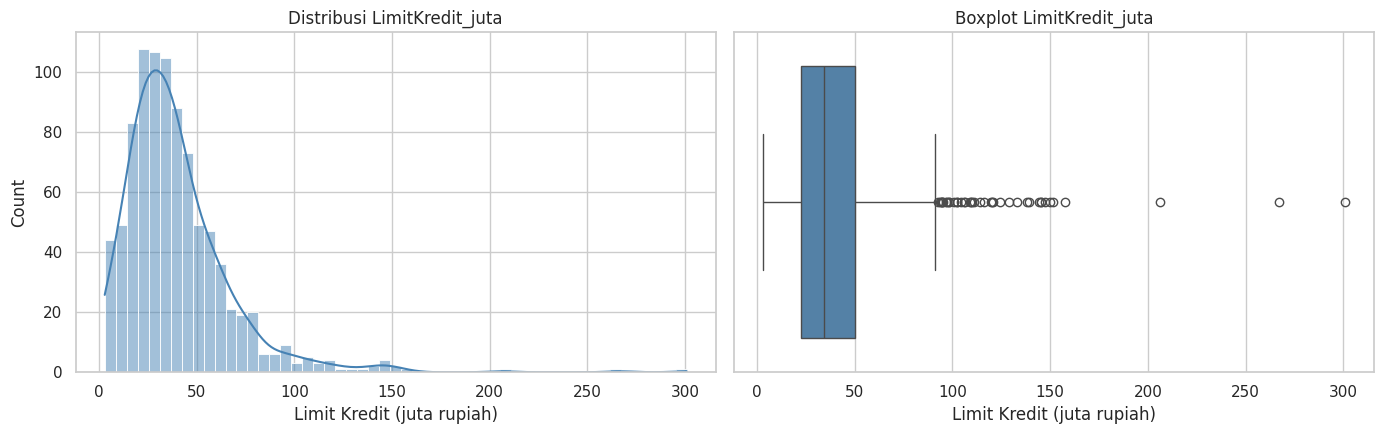

Rata-rata limit : 39.71 juta
Median limit    : 34.45 juta
Standar deviasi : 27.88 juta
Skewness        : 2.775


In [167]:
target = 'LimitKredit_juta'

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(df[target], kde=True, ax=ax[0], color='steelblue')
ax[0].set_title(f'Distribusi {target}')
ax[0].set_xlabel('Limit Kredit (juta rupiah)')

sns.boxplot(x=df[target], ax=ax[1], color='steelblue')
ax[1].set_title(f'Boxplot {target}')
ax[1].set_xlabel('Limit Kredit (juta rupiah)')

plt.tight_layout()
plt.show()

print(f"Rata-rata limit : {df[target].mean():.2f} juta")
print(f"Median limit    : {df[target].median():.2f} juta")
print(f"Standar deviasi : {df[target].std():.2f} juta")
print(f"Skewness        : {df[target].skew():.3f}")

**Cara membaca keluaran di atas.** Target kita bernilai kontinu dan positif dengan sedikit ekor ke kanan. Skewness yang tidak terlalu ekstrem berarti kita belum wajib melakukan transformasi log. Kalau skewness sudah di atas 1, transformasi log biasanya membuat model linear jauh lebih stabil.

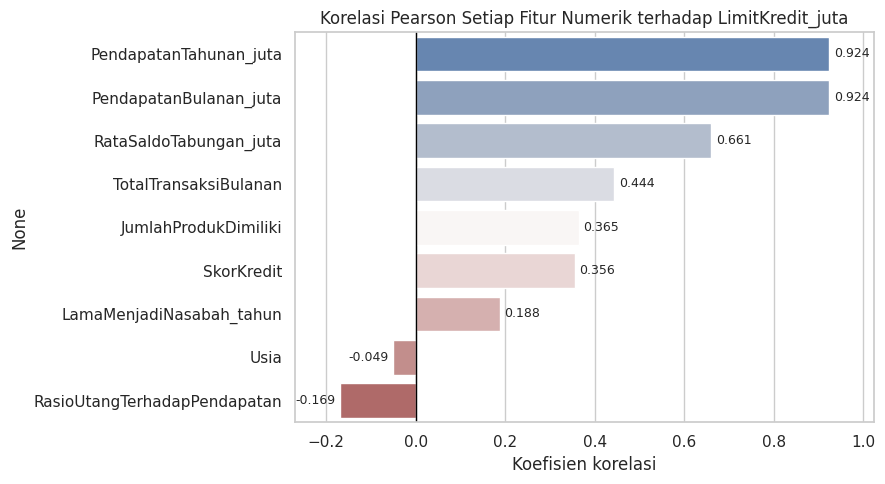

In [158]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
korelasi = df[num_cols].corr()[target].drop(target).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=korelasi.values, y=korelasi.index,
                 hue=korelasi.index, palette='vlag', legend=False)
plt.axvline(0, color='black', linewidth=1)

for i, v in enumerate(korelasi.values):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.3f}',
            va='center',
            ha='left' if v >= 0 else 'right',
            fontsize=9)

# kasih ruang ekstra biar angkanya nggak kepotong di tepi
ax.set_xlim(korelasi.min() - 0.1, korelasi.max() + 0.1)

plt.title(f'Korelasi Pearson Setiap Fitur Numerik terhadap {target}')
plt.xlabel('Koefisien korelasi')
plt.tight_layout()
plt.show()

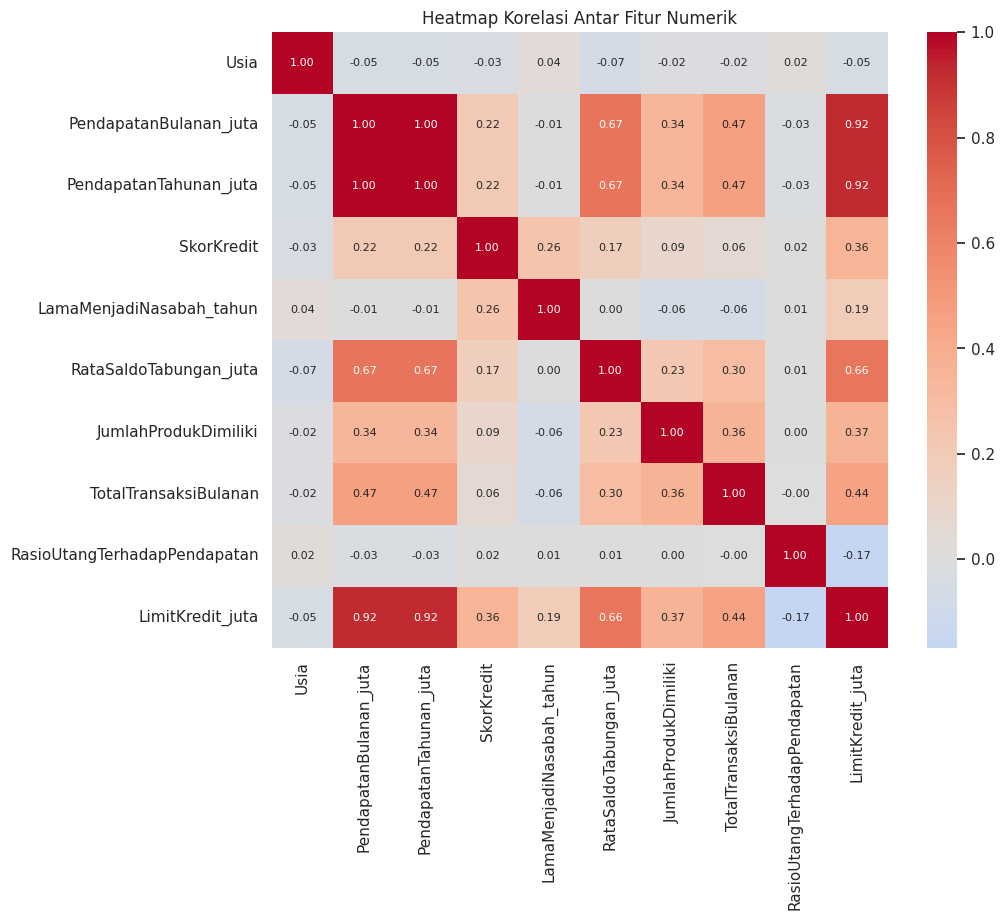

In [168]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, annot_kws={'size': 8})
plt.title('Heatmap Korelasi Antar Fitur Numerik')
plt.show()

**Perhatikan baik-baik.** Pasangan `PendapatanBulanan_juta` dan `PendapatanTahunan_juta` memiliki korelasi mendekati 1. Ini masuk akal karena yang satu adalah kelipatan dari yang lain. Kondisi seperti ini disebut **multikolinearitas** dan akan kita bedah tuntas pada Bagian 6. Untuk sementara biarkan dulu keduanya ada di dalam model supaya kita bisa melihat sendiri masalah yang ditimbulkannya.

## 1.4 Baseline: Model Paling Bodoh yang Bisa Kita Buat

Sebelum membangun model apa pun, kita perlu tolok ukur. Baseline paling sederhana untuk regresi adalah **selalu menebak nilai rata-rata target**. Model apa pun yang kita bangun setelah ini wajib mengalahkan baseline tersebut. Kalau tidak, berarti fitur yang kita punya tidak memberi informasi apa-apa.

In [169]:
y_all = df[target]
baseline_pred = np.full_like(y_all, fill_value=y_all.mean(), dtype=float)

rmse_baseline = np.sqrt(mean_squared_error(y_all, baseline_pred))
mae_baseline = mean_absolute_error(y_all, baseline_pred)

print('=== BASELINE: selalu menebak rata-rata ===')
print(f'Tebakan konstan : {y_all.mean():.2f} juta')
print(f'MAE  baseline   : {mae_baseline:.2f} juta')
print(f'RMSE baseline   : {rmse_baseline:.2f} juta')
print(f'R2   baseline   : {r2_score(y_all, baseline_pred):.4f}')
print()
print('Catatan: R2 baseline selalu 0. Model yang berguna harus punya R2 jauh di atas 0.')

=== BASELINE: selalu menebak rata-rata ===
Tebakan konstan : 39.71 juta
MAE  baseline   : 19.02 juta
RMSE baseline   : 27.86 juta
R2   baseline   : 0.0000

Catatan: R2 baseline selalu 0. Model yang berguna harus punya R2 jauh di atas 0.


---

# Bagian 2: Simple Linear Regression

## 2.1 Bentuk Model

*Simple linear regression* memakai **satu** fitur untuk memprediksi target.

$$\hat{y} = \beta_0 + \beta_1 x$$

dengan $\beta_0$ sebagai intercept, yaitu nilai prediksi ketika $x$ bernilai nol, dan $\beta_1$ sebagai slope, yaitu perubahan prediksi ketika $x$ naik satu satuan.

## 2.2 Kriteria OLS

**Ordinary Least Squares (OLS)** memilih $\beta_0$ dan $\beta_1$ yang meminimalkan jumlah kuadrat galat.

$$\text{SSE} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \sum_{i=1}^{n} (y_i - \beta_0 - \beta_1 x_i)^2$$

Kenapa yang dikuadratkan, bukan nilai mutlaknya. Ada dua alasan praktis. Pertama, fungsi kuadrat bisa diturunkan di semua titik sehingga solusinya dapat dicari secara analitik. Kedua, kesalahan besar dihukum lebih berat, yang biasanya memang kita inginkan pada kasus keuangan.

Dengan menurunkan SSE terhadap $\beta_0$ dan $\beta_1$ lalu menyamakannya dengan nol, kita mendapat rumus tertutup berikut.

$$\beta_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2} \qquad \beta_0 = \bar{y} - \beta_1 \bar{x}$$

Mari kita hitung manual dulu, baru dibandingkan dengan scikit-learn.

In [170]:
x = df['PendapatanBulanan_juta'].values
y = df[target].values

x_bar, y_bar = x.mean(), y.mean()

beta1_manual = np.sum((x - x_bar) * (y - y_bar)) / np.sum((x - x_bar) ** 2)
beta0_manual = y_bar - beta1_manual * x_bar

print('=== PERHITUNGAN MANUAL (rumus tertutup OLS) ===')
print(f'beta_0 (intercept) : {beta0_manual:.4f}')
print(f'beta_1 (slope)     : {beta1_manual:.4f}')

=== PERHITUNGAN MANUAL (rumus tertutup OLS) ===
beta_0 (intercept) : -7.6236
beta_1 (slope)     : 4.0050


In [171]:
model_simple = LinearRegression()
model_simple.fit(x.reshape(-1, 1), y)

print('=== HASIL SCIKIT-LEARN ===')
print(f'beta_0 (intercept) : {model_simple.intercept_:.4f}')
print(f'beta_1 (slope)     : {model_simple.coef_[0]:.4f}')
print()
print('Selisih dengan perhitungan manual:')
print(f'  intercept : {abs(model_simple.intercept_ - beta0_manual):.10f}')
print(f'  slope     : {abs(model_simple.coef_[0] - beta1_manual):.10f}')
print()
print('Keduanya identik. scikit-learn memang menyelesaikan OLS secara analitik, bukan iteratif.')

=== HASIL SCIKIT-LEARN ===
beta_0 (intercept) : -7.6236
beta_1 (slope)     : 4.0050

Selisih dengan perhitungan manual:
  intercept : 0.0000000000
  slope     : 0.0000000000

Keduanya identik. scikit-learn memang menyelesaikan OLS secara analitik, bukan iteratif.


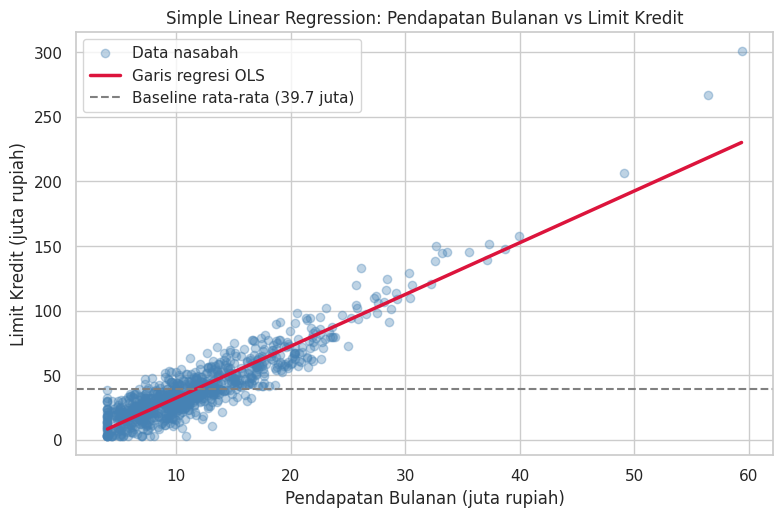

RMSE model simple : 10.64 juta
RMSE baseline     : 27.86 juta
R2   model simple : 0.8542


In [172]:
y_pred_simple = model_simple.predict(x.reshape(-1, 1))

plt.figure(figsize=(9, 5.5))
plt.scatter(x, y, alpha=0.35, label='Data nasabah', color='steelblue')
plt.plot(np.sort(x), model_simple.predict(np.sort(x).reshape(-1, 1)),
         color='crimson', linewidth=2.5, label='Garis regresi OLS')
plt.axhline(y.mean(), color='gray', linestyle='--', linewidth=1.5,
            label=f'Baseline rata-rata ({y.mean():.1f} juta)')
plt.xlabel('Pendapatan Bulanan (juta rupiah)')
plt.ylabel('Limit Kredit (juta rupiah)')
plt.title('Simple Linear Regression: Pendapatan Bulanan vs Limit Kredit')
plt.legend()
plt.show()

print(f'RMSE model simple : {np.sqrt(mean_squared_error(y, y_pred_simple)):.2f} juta')
print(f'RMSE baseline     : {rmse_baseline:.2f} juta')
print(f'R2   model simple : {r2_score(y, y_pred_simple):.4f}')

## 2.3 Cara Membaca Koefisien

Ini bagian yang paling sering diminta oleh pemilik bisnis, jadi harus benar.

- **Slope.** Setiap kenaikan pendapatan bulanan sebesar **1 juta rupiah**, prediksi limit kredit naik sebesar **nilai slope juta rupiah**, dengan asumsi tidak ada faktor lain yang ikut berubah.
- **Intercept.** Prediksi limit ketika pendapatan bulanan nol. Angka ini sering **tidak punya arti bisnis** karena nasabah dengan pendapatan nol tidak akan diberi kartu kredit. Intercept berfungsi sebagai penyesuai posisi garis, bukan sebagai temuan bisnis.
- **Peringatan penting.** Korelasi yang kuat bukan berarti hubungan sebab akibat. Model ini hanya menyatakan bahwa pendapatan dan limit bergerak bersama pada data historis.

Lihat juga sebaran titik pada grafik. Titik-titik di sisi kanan (nasabah berpendapatan tinggi) cenderung berada di atas garis lurus. Ini petunjuk awal bahwa hubungannya mungkin **tidak sepenuhnya linear**, dan itulah yang akan kita tangani dengan *polynomial regression* di Bagian 8.

In [173]:
print('Interpretasi bisnis:')
print(f'  Naik 1 juta pendapatan bulanan -> limit naik sekitar {beta1_manual:.2f} juta rupiah.')
print(f'  Naik 5 juta pendapatan bulanan -> limit naik sekitar {beta1_manual * 5:.2f} juta rupiah.')
print()

contoh = pd.DataFrame({'PendapatanBulanan_juta': [8, 15, 30, 50]})
contoh['PrediksiLimit_juta'] = model_simple.predict(contoh[['PendapatanBulanan_juta']]).round(2)
contoh

Interpretasi bisnis:
  Naik 1 juta pendapatan bulanan -> limit naik sekitar 4.01 juta rupiah.
  Naik 5 juta pendapatan bulanan -> limit naik sekitar 20.03 juta rupiah.



,PendapatanBulanan_juta,PrediksiLimit_juta
0,8,24.42
1,15,52.45
2,30,112.53
3,50,192.63


> ### Giliran Anda (2 menit)
>
> Pada cell prediksi di atas, ganti daftar pendapatan `[8, 15, 30, 50]` menjadi `[8, 15, 30, 50, 200]` lalu jalankan ulang.
>
> Nasabah dengan pendapatan 200 juta per bulan jauh di luar rentang data latih yang maksimalnya sekitar 59 juta. Masuk akalkah angka prediksinya. Diskusikan kenapa memakai model di luar rentang data historis itu berbahaya.

---

# Bagian 3: Multiple Linear Regression

## 3.1 Dari Satu Fitur ke Banyak Fitur

Limit kredit tentu tidak hanya ditentukan oleh pendapatan. Skor kredit, lama relasi, dan rasio utang juga berperan. *Multiple linear regression* memperluas model tadi.

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p$$

Dalam bentuk matriks, dengan $X$ berukuran $n \times (p+1)$ karena ada kolom konstanta 1 untuk intercept.

$$\hat{y} = X\beta$$

Solusi OLS-nya punya bentuk tertutup yang disebut **normal equation**.

$$\beta = (X^\top X)^{-1} X^\top y$$

## 3.2 Menyiapkan Fitur Kategorikal

Model linear hanya menerima angka, jadi `JenisPekerjaan` perlu diubah menjadi kolom biner lewat **one-hot encoding**. Kita membuang satu kategori sebagai *reference category* untuk menghindari *dummy variable trap*, yaitu kondisi ketika kolom-kolom dummy saling menjumlah menjadi kolom konstanta sehingga $X^\top X$ menjadi singular.

In [174]:
df_model = df.drop(columns=['IDNasabah']).copy()

df_model = pd.get_dummies(df_model, columns=['JenisPekerjaan'],
                          drop_first=True, dtype=float)

print('Kolom setelah one-hot encoding:')
for c in df_model.columns:
    print(' -', c)
print()
print('Kategori "Karyawan" dijadikan reference category karena drop_first=True.')
df_model.head()

Kolom setelah one-hot encoding:
 - Usia
 - PendapatanBulanan_juta
 - PendapatanTahunan_juta
 - SkorKredit
 - LamaMenjadiNasabah_tahun
 - RataSaldoTabungan_juta
 - JumlahProdukDimiliki
 - TotalTransaksiBulanan
 - RasioUtangTerhadapPendapatan
 - LimitKredit_juta
 - JenisPekerjaan_PNS
 - JenisPekerjaan_Profesional
 - JenisPekerjaan_Wiraswasta

Kategori "Karyawan" dijadikan reference category karena drop_first=True.


,Usia,PendapatanBulanan_juta,PendapatanTahunan_juta,SkorKredit,LamaMenjadiNasabah_tahun,RataSaldoTabungan_juta,JumlahProdukDimiliki,TotalTransaksiBulanan,RasioUtangTerhadapPendapatan,LimitKredit_juta,JenisPekerjaan_PNS,JenisPekerjaan_Profesional,JenisPekerjaan_Wiraswasta
0,59,22.53,269.54,721,4,49.76,6,29,0.295,95.31,0.0,0.0,0.0
1,29,15.33,184.94,594,1,32.61,3,19,0.371,46.87,1.0,0.0,0.0
2,23,6.56,78.73,624,1,5.45,2,26,0.410,14.96,1.0,0.0,0.0
3,50,12.78,152.64,598,4,30.43,2,42,0.289,42.64,0.0,1.0,0.0
4,38,19.41,232.94,666,6,32.65,2,45,0.448,57.17,1.0,0.0,0.0


In [175]:
X = df_model.drop(columns=[target])
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Data latih : {X_train.shape[0]} baris, {X_train.shape[1]} fitur')
print(f'Data uji   : {X_test.shape[0]} baris, {X_test.shape[1]} fitur')
print()
print('Data uji tidak boleh disentuh sama sekali selama proses pemodelan.')
print('Data uji adalah simulasi nasabah baru yang belum pernah dilihat model.')

Data latih : 720 baris, 12 fitur
Data uji   : 180 baris, 12 fitur

Data uji tidak boleh disentuh sama sekali selama proses pemodelan.
Data uji adalah simulasi nasabah baru yang belum pernah dilihat model.


## 3.3 Menyelesaikan Normal Equation Secara Manual

Kita implementasikan $\beta = (X^\top X)^{-1} X^\top y$ dengan numpy, lalu bandingkan hasilnya dengan scikit-learn.

In [176]:
# Tambahkan kolom konstanta 1 untuk intercept
X_train_np = np.column_stack([np.ones(len(X_train)), X_train.values])
y_train_np = y_train.values

XtX = X_train_np.T @ X_train_np
Xty = X_train_np.T @ y_train_np
beta_manual = np.linalg.inv(XtX) @ Xty

print('=== NORMAL EQUATION MANUAL ===')
print(f'Ukuran matriks X : {X_train_np.shape}')
print(f'Ukuran X^T X     : {XtX.shape}')
print(f'Intercept        : {beta_manual[0]:.4f}')
print()
for nama, koef in zip(X_train.columns, beta_manual[1:]):
    print(f'  {nama:<32} {koef:>10.4f}')

=== NORMAL EQUATION MANUAL ===
Ukuran matriks X : (720, 13)
Ukuran X^T X     : (13, 13)
Intercept        : -34.6640

  Usia                                 0.0085
  PendapatanBulanan_juta              -3.8073
  PendapatanTahunan_juta               0.6127
  SkorKredit                           0.0515
  LamaMenjadiNasabah_tahun             0.8208
  RataSaldoTabungan_juta               0.0881
  JumlahProdukDimiliki                 1.3578
  TotalTransaksiBulanan                0.0301
  RasioUtangTerhadapPendapatan       -41.2077
  JenisPekerjaan_PNS                   2.1088
  JenisPekerjaan_Profesional           6.6219
  JenisPekerjaan_Wiraswasta           -3.8241


In [177]:
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

hasil_koef = pd.DataFrame({
    'fitur': ['intercept'] + list(X_train.columns),
    'manual_numpy': beta_manual,
    'sklearn': [model_multi.intercept_] + list(model_multi.coef_),
})
hasil_koef['selisih_absolut'] = (hasil_koef['manual_numpy'] - hasil_koef['sklearn']).abs()
hasil_koef.round(6)

,fitur,manual_numpy,sklearn,selisih_absolut
0,intercept,-34.663985,-34.663985,0.0
1,Usia,0.008454,0.008454,0.0
2,PendapatanBulanan_juta,-3.807298,-3.807298,0.0
3,PendapatanTahunan_juta,0.612691,0.612691,0.0
4,SkorKredit,0.051472,0.051472,0.0
5,LamaMenjadiNasabah_tahun,0.820831,0.820831,0.0
6,RataSaldoTabungan_juta,0.088094,0.088094,0.0
7,JumlahProdukDimiliki,1.357760,1.357760,0.0
8,TotalTransaksiBulanan,0.030142,0.030142,0.0
9,RasioUtangTerhadapPendapatan,-41.207717,-41.207717,0.0


Kedua pendekatan menghasilkan angka yang praktis sama. Selisih yang muncul hanya di orde $10^{-8}$ atau lebih kecil, yaitu galat pembulatan aritmetika komputer. Perlu dicatat, scikit-learn sebenarnya tidak menghitung invers matriks secara langsung melainkan memakai dekomposisi SVD yang lebih stabil secara numerik, tetapi solusi matematisnya identik.

In [178]:
pred_train = model_multi.predict(X_train)
pred_test = model_multi.predict(X_test)

print('=== PERBANDINGAN TIGA MODEL ===')
print(f"{'Model':<34}{'RMSE test':>12}{'R2 test':>12}")
print('-' * 58)
# Baseline dievaluasi di data uji memakai rata-rata data LATIH, karena rata-rata
# data uji tidak boleh diketahui saat memprediksi. Karena itu R2-nya tidak persis
# nol, melainkan sedikit negatif.
baseline_test = np.full(len(y_test), y_train.mean())
print(f"{'Baseline (rata-rata)':<34}"
      f"{np.sqrt(mean_squared_error(y_test, baseline_test)):>12.2f}"
      f"{r2_score(y_test, baseline_test):>12.4f}")

xs_test = X_test[['PendapatanBulanan_juta']].values
print(f"{'Simple LR (1 fitur)':<34}"
      f"{np.sqrt(mean_squared_error(y_test, model_simple.predict(xs_test))):>12.2f}"
      f"{r2_score(y_test, model_simple.predict(xs_test)):>12.4f}")

print(f"{'Multiple LR (semua fitur)':<34}"
      f"{np.sqrt(mean_squared_error(y_test, pred_test)):>12.2f}"
      f"{r2_score(y_test, pred_test):>12.4f}")

=== PERBANDINGAN TIGA MODEL ===
Model                                RMSE test     R2 test
----------------------------------------------------------
Baseline (rata-rata)                     30.63     -0.0008
Simple LR (1 fitur)                      11.41      0.8612
Multiple LR (semua fitur)                 7.46      0.9406


Lonjakan performa dari satu fitur ke banyak fitur terlihat jelas. Namun jangan berhenti di sini. Coba amati tabel koefisien tadi, khususnya `PendapatanBulanan_juta` dan `PendapatanTahunan_juta`. Nilainya besar dan berlawanan tanda, padahal secara logika keduanya sama-sama mengukur kemampuan bayar. Gejala ini adalah tanda multikolinearitas yang akan kita diagnosis di Bagian 6.

---

# Bagian 4: OLS vs SGD

## 4.1 Dua Cara Mencari Koefisien yang Sama

Sampai di sini kita sudah punya model. Pertanyaannya, bagaimana sebenarnya komputer menemukan nilai $\beta$. Ada dua mazhab.

**Cara pertama, OLS lewat normal equation.** Kita selesaikan persamaannya secara aljabar, sekali jalan, langsung dapat jawaban pasti.

$$\beta = (X^\top X)^{-1} X^\top y$$

**Cara kedua, Stochastic Gradient Descent (SGD).** Kita tebak $\beta$ secara acak, lalu memperbaikinya sedikit demi sedikit ke arah yang menurunkan galat. Arah perbaikan ditentukan oleh gradien fungsi biaya.

$$\beta \leftarrow \beta - \eta \nabla_\beta J(\beta)$$

dengan $\eta$ sebagai *learning rate* dan $J(\beta)$ sebagai fungsi biaya, yaitu MSE. Disebut *stochastic* karena gradien dihitung dari satu sampel atau satu batch kecil pada tiap langkah, bukan dari seluruh data sekaligus.

## 4.2 Kenapa Repot Pakai SGD Kalau OLS Sudah Eksak

Normal equation mengharuskan kita menghitung invers dari $X^\top X$, matriks berukuran $p \times p$ dengan $p$ adalah jumlah fitur. Biayanya sekitar $O(p^3)$. Selama fitur masih puluhan, ini tidak jadi soal. Masalahnya muncul pada tiga situasi berikut.

1. **Jumlah fitur sangat besar.** Pada data teks atau data hasil one-hot encoding dengan ribuan kategori, $p$ bisa mencapai puluhan ribu. Menghitung invers matriks sebesar itu menjadi sangat mahal.
2. **Data tidak muat di memori.** Normal equation butuh seluruh data sekaligus. SGD bisa memproses data per potongan lewat metode `partial_fit`, sehingga cocok untuk data transaksi bank yang jumlahnya ratusan juta baris.
3. **Model perlu diperbarui terus menerus.** SGD mendukung *online learning*, yaitu memperbarui model saat data baru berdatangan tanpa melatih ulang dari nol.

Sebaliknya, SGD punya harga yang harus dibayar. Hasilnya **hampiran, bukan eksak**, dan performanya sangat bergantung pada *learning rate* serta **penyekalaan fitur**. Kita buktikan sekarang.

## 4.3 Catatan tentang scikit-learn

Perlu diluruskan sejak awal karena sering menimbulkan kebingungan. Pada scikit-learn, `LinearRegression` **tidak punya parameter optimizer** sama sekali. Tidak ada argumen `learning_rate`, tidak ada `max_iter`, tidak ada `optimizer`. Alasannya sederhana, kelas tersebut menyelesaikan OLS secara analitik lewat dekomposisi matriks sehingga tidak ada yang perlu diiterasi.

Kalau kita ingin mengendalikan proses optimasi, kita harus memakai kelas yang berbeda, yaitu **`SGDRegressor`**. Kelas inilah yang menyediakan parameter seperti `learning_rate`, `eta0`, `max_iter`, `tol`, dan `penalty`. Jadi pilihan optimizer di scikit-learn ditentukan lewat **pemilihan kelas model**, bukan lewat argumen di dalam satu kelas.

In [179]:
print('Parameter LinearRegression (penyelesai analitik):')
print(' ', sorted(LinearRegression().get_params().keys()))
print()
print('Parameter SGDRegressor (penyelesai iteratif):')
print(' ', sorted(SGDRegressor().get_params().keys()))
print()
print('Perhatikan: learning_rate, eta0, max_iter, dan tol hanya ada di SGDRegressor.')

Parameter LinearRegression (penyelesai analitik):
  ['copy_X', 'fit_intercept', 'n_jobs', 'positive']

Parameter SGDRegressor (penyelesai iteratif):
  ['alpha', 'average', 'early_stopping', 'epsilon', 'eta0', 'fit_intercept', 'l1_ratio', 'learning_rate', 'loss', 'max_iter', 'n_iter_no_change', 'penalty', 'power_t', 'random_state', 'shuffle', 'tol', 'validation_fraction', 'verbose', 'warm_start']

Perhatikan: learning_rate, eta0, max_iter, dan tol hanya ada di SGDRegressor.


## 4.4 Percobaan 1: SGD Tanpa Perubahan Fitur

Fitur pada dataset kita punya rentang yang sangat berbeda. `SkorKredit` bergerak di ratusan, sementara `RasioUtangTerhadapPendapatan` bergerak di bawah satu. Perbedaan skala seperti ini membuat permukaan fungsi biaya menjadi sangat lonjong. Gradient descent akan memantul di dinding lembah yang curam dan merambat sangat lambat di arah yang landai.

In [180]:
print('Rentang nilai tiap fitur pada data latih:')
rentang = pd.DataFrame({
    'min': X_train.min(),
    'max': X_train.max(),
    'std': X_train.std(),
}).round(3)
rentang['rasio_skala'] = (rentang['std'] / rentang['std'].min()).round(1)
rentang.sort_values('rasio_skala', ascending=False)

Rentang nilai tiap fitur pada data latih:


,min,max,std,rasio_skala
PendapatanTahunan_juta,47.570,678.840,75.879,782.3
SkorKredit,444.000,837.000,59.550,613.9
RataSaldoTabungan_juta,0.100,122.040,19.060,196.5
TotalTransaksiBulanan,3.000,75.000,12.626,130.2
Usia,22.000,65.000,12.520,129.1
PendapatanBulanan_juta,4.000,56.420,6.323,65.2
LamaMenjadiNasabah_tahun,0.000,25.000,5.636,58.1
JumlahProdukDimiliki,1.000,6.000,1.114,11.5
JenisPekerjaan_Wiraswasta,0.000,1.000,0.404,4.2
JenisPekerjaan_PNS,0.000,1.000,0.397,4.1


In [181]:
sgd_tanpa_scaling = SGDRegressor(
    max_iter=1000,
    tol=1e-4,
    eta0=0.01,
    learning_rate='invscaling',
    random_state=RANDOM_STATE,
)
sgd_tanpa_scaling.fit(X_train, y_train)
pred_sgd_raw = sgd_tanpa_scaling.predict(X_test)

rmse_sgd_raw = np.sqrt(mean_squared_error(y_test, pred_sgd_raw))
r2_sgd_raw = r2_score(y_test, pred_sgd_raw)

print('=== SGD TANPA PENYEKALAAN ===')
print(f'Jumlah iterasi terpakai : {sgd_tanpa_scaling.n_iter_}')
if np.isfinite(rmse_sgd_raw):
    print(f'RMSE test : {rmse_sgd_raw:,.2f} juta')
    print(f'R2   test : {r2_sgd_raw:,.4f}')
else:
    print('RMSE test : tidak terhingga (proses optimasi divergen)')
print()
print('Bandingkan dengan OLS:')
print(f'RMSE test OLS : {np.sqrt(mean_squared_error(y_test, pred_test)):.2f} juta')

=== SGD TANPA PENYEKALAAN ===
Jumlah iterasi terpakai : 116
RMSE test : 152,882,850,490,343.81 juta
R2   test : -24,925,261,070,445,026,402,631,680.0000

Bandingkan dengan OLS:
RMSE test OLS : 7.46 juta


Hasilnya kacau. Nilai galatnya bisa jauh lebih besar daripada OLS, bahkan berpotensi meledak menjadi tak terhingga. Ini bukan karena SGD adalah algoritma yang buruk, melainkan karena kita memberinya data dengan skala yang timpang.

## 4.5 Percobaan 2: SGD dengan StandardScaler

`StandardScaler` mengubah setiap fitur menjadi rata-rata nol dan standar deviasi satu.

$$z = \frac{x - \mu}{\sigma}$$

Satu hal yang wajib diperhatikan, *scaler* di-*fit* **hanya pada data latih**, lalu dipakai untuk mentransformasi data uji. Kalau *scaler* di-*fit* pada seluruh data, informasi dari data uji bocor ke proses pelatihan. Kebocoran seperti ini disebut *data leakage* dan membuat evaluasi kita menipu diri sendiri. Memakai `Pipeline` adalah cara paling aman untuk menghindarinya.

In [182]:
pipe_sgd = Pipeline([
    ('scaler', StandardScaler()),
    ('sgd', SGDRegressor(
        max_iter=5000,
        tol=1e-5,
        eta0=0.01,
        learning_rate='invscaling',
        random_state=RANDOM_STATE,
    )),
])
pipe_sgd.fit(X_train, y_train)
pred_sgd = pipe_sgd.predict(X_test)

rmse_sgd = np.sqrt(mean_squared_error(y_test, pred_sgd))
rmse_ols = np.sqrt(mean_squared_error(y_test, pred_test))

print('=== SGD DENGAN PENYEKALAAN ===')
print(f'Jumlah iterasi terpakai : {pipe_sgd.named_steps["sgd"].n_iter_}')
print(f'RMSE test SGD  : {rmse_sgd:.2f} juta')
print(f'R2   test SGD  : {r2_score(y_test, pred_sgd):.4f}')
print()
print(f'RMSE test OLS  : {rmse_ols:.2f} juta')
print(f'R2   test OLS  : {r2_score(y_test, pred_test):.4f}')
print()
print(f'Selisih RMSE   : {abs(rmse_sgd - rmse_ols):.3f} juta')
print()
print('Setelah fitur diskalakan, SGD mendekati hasil OLS dengan sangat rapat.')

=== SGD DENGAN PENYEKALAAN ===
Jumlah iterasi terpakai : 19
RMSE test SGD  : 7.45 juta
R2   test SGD  : 0.9407

RMSE test OLS  : 7.46 juta
R2   test OLS  : 0.9406

Selisih RMSE   : 0.006 juta

Setelah fitur diskalakan, SGD mendekati hasil OLS dengan sangat rapat.


> ### Giliran Anda (2 menit)
>
> Pada pipeline SGD di atas, ubah `max_iter=5000` menjadi `max_iter=50` lalu jalankan ulang.
>
> Perhatikan RMSE-nya. Apa yang terjadi ketika iterasi dipangkas, dan kenapa OLS tidak punya masalah semacam ini sama sekali.

## 4.6 Pengaruh Learning Rate

*Learning rate* menentukan besar langkah perbaikan pada tiap iterasi. Terlalu kecil, model merambat lambat dan berhenti sebelum sampai. Terlalu besar, model melompati titik minimum dan justru menjauh. Mari kita uji beberapa nilai.

In [183]:
hasil_eta = []

for eta in [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('sgd', SGDRegressor(max_iter=2000, tol=1e-5, eta0=eta,
                             learning_rate='constant', random_state=RANDOM_STATE)),
    ])
    pipe.fit(X_train, y_train)
    p = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, p))
    hasil_eta.append({
        'learning_rate (eta0)': eta,
        'iterasi': pipe.named_steps['sgd'].n_iter_,
        'RMSE_test': rmse if np.isfinite(rmse) else np.inf,
        'R2_test': r2_score(y_test, p),
    })

df_eta = pd.DataFrame(hasil_eta)
df_eta['catatan'] = np.where(
    ~np.isfinite(df_eta['RMSE_test']) | (df_eta['RMSE_test'] > 100), 'divergen atau tidak stabil',
    np.where(df_eta['RMSE_test'] > rmse_ols * 1.10, 'belum konvergen', 'baik')
)
df_eta.round(4)

,learning_rate (eta0),iterasi,RMSE_test,R2_test,catatan
0,0.0001,146,7.392000e+00,9.417000e-01,baik
1,0.0010,19,7.457600e+00,9.407000e-01,baik
2,0.0100,10,7.149900e+00,9.455000e-01,baik
3,0.1000,7,1.397830e+01,7.916000e-01,belum konvergen
4,0.5000,6,1.966137e+12,-4.122397e+21,divergen atau tidak stabil
5,1.0000,9,9.766306e+12,-1.017145e+23,divergen atau tidak stabil


Terlihat pola yang khas. Nilai `eta0` yang sangat kecil membuat model berhenti sebelum mencapai solusi optimal. Nilai yang terlalu besar membuat iterasi meledak. Ada rentang nilai di tengah yang bekerja dengan baik, dan menemukannya adalah bagian dari *hyperparameter tuning*.

## 4.7 Melihat Proses Iterasinya Secara Langsung

Bagian ini bersifat opsional dan boleh dilewati jika waktu mepet. Tujuannya supaya proses iterasi SGD tidak terasa seperti kotak hitam. Kita jalankan `partial_fit` satu epoch demi satu epoch, lalu merekam nilai MSE pada tiap epoch. Metode `partial_fit` inilah yang dipakai untuk *online learning* di dunia nyata.

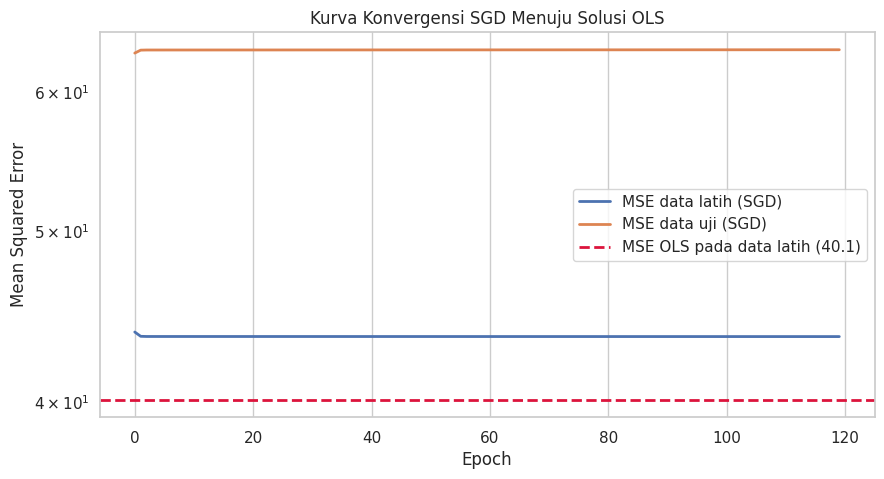

MSE latih epoch pertama : 43.84
MSE latih epoch terakhir: 43.58
MSE latih solusi OLS    : 40.13

SGD merayap turun mendekati garis merah, yaitu solusi eksak yang langsung didapat OLS.


In [184]:
scaler_demo = StandardScaler().fit(X_train)
Xtr_s = scaler_demo.transform(X_train)
Xte_s = scaler_demo.transform(X_test)

sgd_demo = SGDRegressor(learning_rate='constant', eta0=0.01,
                        penalty=None, random_state=RANDOM_STATE)

riwayat_train, riwayat_test = [], []
N_EPOCH = 120

for epoch in range(N_EPOCH):
    sgd_demo.partial_fit(Xtr_s, y_train)
    riwayat_train.append(mean_squared_error(y_train, sgd_demo.predict(Xtr_s)))
    riwayat_test.append(mean_squared_error(y_test, sgd_demo.predict(Xte_s)))

mse_ols_train = mean_squared_error(y_train, pred_train)

plt.figure(figsize=(10, 5))
plt.plot(riwayat_train, label='MSE data latih (SGD)', linewidth=2)
plt.plot(riwayat_test, label='MSE data uji (SGD)', linewidth=2)
plt.axhline(mse_ols_train, color='crimson', linestyle='--', linewidth=2,
            label=f'MSE OLS pada data latih ({mse_ols_train:.1f})')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Kurva Konvergensi SGD Menuju Solusi OLS')
plt.legend()
plt.yscale('log')
plt.show()

print(f'MSE latih epoch pertama : {riwayat_train[0]:.2f}')
print(f'MSE latih epoch terakhir: {riwayat_train[-1]:.2f}')
print(f'MSE latih solusi OLS    : {mse_ols_train:.2f}')
print()
print('SGD merayap turun mendekati garis merah, yaitu solusi eksak yang langsung didapat OLS.')

## 4.8 Kapan SGD Benar-benar Menang

Pada dataset 900 baris seperti ini, OLS jelas lebih praktis. Keunggulan SGD baru terasa ketika datanya besar. Mari kita buktikan dengan data buatan berukuran 200 ribu baris dan 300 fitur, ukuran yang wajar untuk data transaksi harian sebuah bank.

In [185]:
# CATATAN: cell ini murni mengukur WAKTU LATIH, bukan kemampuan generalisasi.
# Karena itu tidak ada pembagian latih dan uji, dan RMSE yang dicetak adalah
# RMSE in-sample yang hanya dipakai untuk memastikan kedua metode sampai pada
# solusi yang setara. Jangan tiru pola ini saat mengevaluasi model sungguhan,
# gunakan alur train test split seperti pada Bagian 3 sampai 8.
X_big, y_big = make_regression(n_samples=200_000, n_features=300,
                               noise=15.0, random_state=RANDOM_STATE)

scaler_big = StandardScaler().fit(X_big)
X_big_s = scaler_big.transform(X_big)

t0 = time.time()
ols_big = LinearRegression().fit(X_big, y_big)
waktu_ols = time.time() - t0
rmse_ols_big = np.sqrt(mean_squared_error(y_big, ols_big.predict(X_big)))

t0 = time.time()
sgd_big = SGDRegressor(max_iter=25, tol=None, eta0=0.01,
                       learning_rate='invscaling', random_state=RANDOM_STATE)
sgd_big.fit(X_big_s, y_big)
waktu_sgd = time.time() - t0
rmse_sgd_big = np.sqrt(mean_squared_error(y_big, sgd_big.predict(X_big_s)))

print(f'Ukuran data: {X_big.shape[0]:,} baris x {X_big.shape[1]} fitur')
print()
print(f"{'Metode':<16}{'Waktu latih (detik)':>22}{'RMSE in-sample':>18}")
print('-' * 56)
print(f"{'OLS':<16}{waktu_ols:>22.3f}{rmse_ols_big:>18.3f}")
print(f"{'SGD (25 epoch)':<16}{waktu_sgd:>22.3f}{rmse_sgd_big:>18.3f}")
print()
print('Perlu diingat, OLS di sini masih sanggup karena p=300 relatif kecil.')
print('Ketika p menembus puluhan ribu, biaya O(p^3) membuat OLS praktis tidak terpakai,')
print('sementara SGD tetap berjalan karena biayanya linear terhadap jumlah fitur.')

Ukuran data: 200,000 baris x 300 fitur

Metode             Waktu latih (detik)    RMSE in-sample
--------------------------------------------------------
OLS                             10.388            14.994
SGD (25 epoch)                   7.970            15.247

Perlu diingat, OLS di sini masih sanggup karena p=300 relatif kecil.
Ketika p menembus puluhan ribu, biaya O(p^3) membuat OLS praktis tidak terpakai,
sementara SGD tetap berjalan karena biayanya linear terhadap jumlah fitur.


## 4.9 Ringkasan OLS vs SGD

| Aspek | OLS (Normal Equation) | SGD |
|-------|----------------------|-----|
| Jenis solusi | Eksak dan analitik | Hampiran dan iteratif |
| Rumus inti | $\beta = (X^\top X)^{-1} X^\top y$ | $\beta \leftarrow \beta - \eta \nabla J(\beta)$ |
| Kompleksitas | Sekitar $O(np^2 + p^3)$ | Sekitar $O(n p)$ per epoch |
| Hyperparameter | Tidak ada | Learning rate, jumlah epoch, penalty, tol |
| Butuh penyekalaan fitur | Tidak | **Wajib** |
| Data sangat besar | Berat, butuh semua data di memori | Ringan, bisa `partial_fit` per batch |
| Fitur sangat banyak | Tidak praktis | Tetap jalan |
| Online learning | Tidak bisa | Bisa |
| Reprodusibilitas | Selalu sama | Bergantung pada `random_state` |
| Kelas di scikit-learn | `LinearRegression` | `SGDRegressor` |

**Aturan praktis.** Selama data masih muat di memori dan jumlah fitur di bawah beberapa ribu, pakai `LinearRegression`. Beralihlah ke `SGDRegressor` ketika data terlalu besar, fitur terlalu banyak, atau model perlu diperbarui secara berkala mengikuti data yang terus mengalir.

---

# Bagian 5: Evaluating and Interpreting Regression Result

Model sudah jadi. Sekarang bagian yang menentukan apakah model boleh dipakai atau tidak.

## 5.1 Metrik Evaluasi

| Metrik | Rumus | Satuan | Karakter |
|--------|-------|--------|----------|
| MAE | $\frac{1}{n}\sum \lvert y_i - \hat{y}_i \rvert$ | Sama dengan target | Tahan terhadap outlier, mudah dijelaskan ke pihak bisnis |
| MSE | $\frac{1}{n}\sum (y_i - \hat{y}_i)^2$ | Kuadrat satuan target | Menghukum kesalahan besar, sulit diinterpretasi langsung |
| RMSE | $\sqrt{\text{MSE}}$ | Sama dengan target | Menghukum kesalahan besar tetapi satuannya tetap terbaca |
| MAPE | $\frac{100}{n}\sum \lvert \frac{y_i - \hat{y}_i}{y_i} \rvert$ | Persen | Enak dibaca, tetapi meledak bila ada target mendekati nol |
| $R^2$ | $1 - \frac{SS_{res}}{SS_{tot}}$ | Tanpa satuan | Proporsi variasi target yang berhasil dijelaskan model |
| Adjusted $R^2$ | $1 - \frac{(1-R^2)(n-1)}{n-p-1}$ | Tanpa satuan | Sama seperti $R^2$ tetapi memberi denda untuk tiap fitur tambahan |

**Kenapa Adjusted $R^2$ diperlukan.** Nilai $R^2$ **tidak pernah turun** ketika kita menambahkan fitur, sekalipun fitur itu berisi angka acak. Adjusted $R^2$ mengoreksi hal ini dengan memberi denda atas setiap fitur tambahan, sehingga lebih adil untuk membandingkan dua model dengan jumlah fitur berbeda.

**Memilih metrik untuk konteks bank.** Kalau salah prediksi 50 juta dan salah prediksi 5 juta punya bobot masalah yang sebanding per rupiahnya, pakai MAE. Kalau kesalahan besar berpotensi menimbulkan kerugian tak proporsional, misalnya limit yang terlalu tinggi pada nasabah berisiko, pakai RMSE karena metrik itu menghukum kesalahan besar lebih keras.

In [186]:
def evaluasi_regresi(y_true, y_pred, n_fitur, label=''):
    n = len(y_true)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_fitur - 1)
    return {
        'set': label,
        'n': n,
        'MAE': round(mae, 3),
        'RMSE': round(rmse, 3),
        'MAPE_persen': round(mape, 2),
        'R2': round(r2, 4),
        'Adj_R2': round(adj_r2, 4),
    }


p_fitur = X_train.shape[1]
tabel_eval = pd.DataFrame([
    evaluasi_regresi(y_train.values, pred_train, p_fitur, 'Data latih'),
    evaluasi_regresi(y_test.values, pred_test, p_fitur, 'Data uji'),
])
tabel_eval

,set,n,MAE,RMSE,MAPE_persen,R2,Adj_R2
0,Data latih,720,4.755,6.335,21.05,0.9454,0.9445
1,Data uji,180,4.727,7.461,18.33,0.9406,0.9364


In [187]:
rmse_test_ols = np.sqrt(mean_squared_error(y_test, pred_test))
rata_target = y_test.mean()

print('=== TERJEMAHAN KE BAHASA BISNIS ===')
print(f'Rata-rata limit kredit pada data uji : {rata_target:.2f} juta rupiah')
print(f'RMSE model                           : {rmse_test_ols:.2f} juta rupiah')
print(f'RMSE relatif terhadap rata-rata      : {rmse_test_ols / rata_target * 100:.1f} persen')
print()
print(f'Artinya, tebakan limit dari model rata-rata meleset sekitar {rmse_test_ols:.1f} juta rupiah')
print(f'dari limit sebenarnya, atau sekitar {rmse_test_ols / rata_target * 100:.0f} persen dari nilai limit rata-rata.')
print()
print(f'Model menjelaskan {r2_score(y_test, pred_test) * 100:.1f} persen variasi limit kredit antar nasabah.')

=== TERJEMAHAN KE BAHASA BISNIS ===
Rata-rata limit kredit pada data uji : 40.39 juta rupiah
RMSE model                           : 7.46 juta rupiah
RMSE relatif terhadap rata-rata      : 18.5 persen

Artinya, tebakan limit dari model rata-rata meleset sekitar 7.5 juta rupiah
dari limit sebenarnya, atau sekitar 18 persen dari nilai limit rata-rata.

Model menjelaskan 94.1 persen variasi limit kredit antar nasabah.


## 5.2 Analisis Residual

Metrik hanya memberi satu angka ringkasan. Residual, yaitu selisih $y - \hat{y}$, memberi tahu kita **di mana** model salah dan **apakah kesalahannya punya pola**. Model linear yang sehat menghasilkan residual yang menyebar acak di sekitar nol tanpa pola apa pun.

Empat hal yang kita cari.

1. **Linearitas.** Residual versus nilai prediksi harus terlihat seperti awan titik tanpa bentuk. Kalau melengkung seperti huruf U, berarti ada hubungan nonlinear yang belum tertangkap model.
2. **Homoskedastisitas.** Lebar sebaran residual harus seragam dari kiri ke kanan. Kalau menyerupai corong yang melebar, artinya ragam galat tidak konstan dan uji statistik pada koefisien menjadi tidak valid.
3. **Normalitas residual.** Diperlukan agar *p-value* dan selang kepercayaan bisa dipercaya. Diperiksa dengan histogram dan Q-Q plot.
4. **Tidak ada outlier ekstrem.** Beberapa titik dengan residual sangat besar bisa menyeret garis regresi.

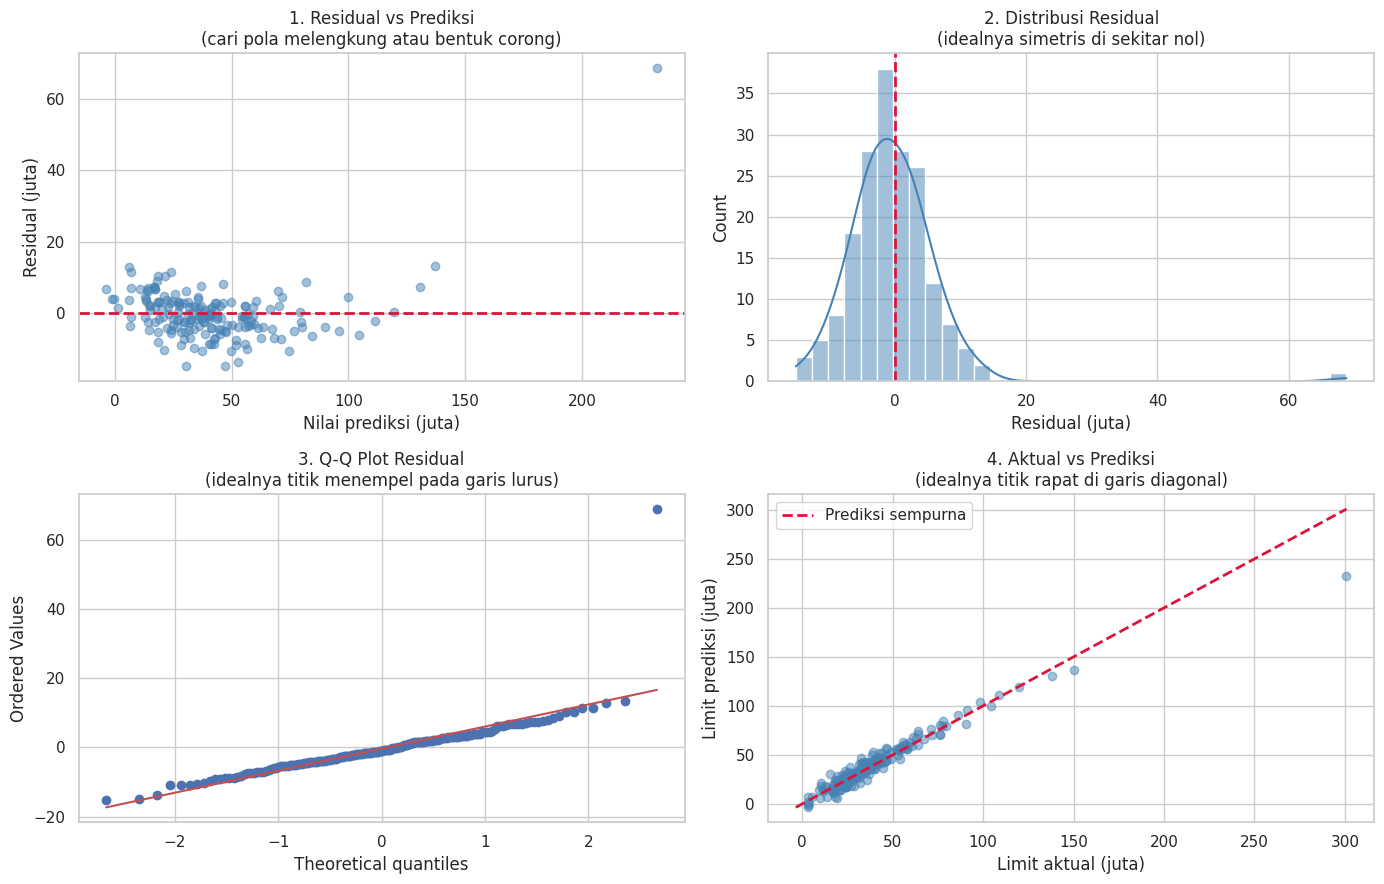

Rata-rata residual : -0.3853 (idealnya mendekati nol)
Standar deviasi    : 7.451
Skewness residual  : 4.376

Uji Shapiro-Wilk untuk normalitas residual: p-value = 0.0000
p-value di atas 0.05 berarti kita belum punya bukti kuat bahwa residual tidak normal.


In [188]:
residual = y_test.values - pred_test

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].scatter(pred_test, residual, alpha=0.5, color='steelblue')
axes[0, 0].axhline(0, color='crimson', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Nilai prediksi (juta)')
axes[0, 0].set_ylabel('Residual (juta)')
axes[0, 0].set_title('1. Residual vs Prediksi\n(cari pola melengkung atau bentuk corong)')

sns.histplot(residual, kde=True, ax=axes[0, 1], color='steelblue')
axes[0, 1].axvline(0, color='crimson', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Residual (juta)')
axes[0, 1].set_title('2. Distribusi Residual\n(idealnya simetris di sekitar nol)')

scp.probplot(residual, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('3. Q-Q Plot Residual\n(idealnya titik menempel pada garis lurus)')

axes[1, 1].scatter(y_test, pred_test, alpha=0.5, color='steelblue')
lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
axes[1, 1].plot(lims, lims, color='crimson', linestyle='--', linewidth=2,
                label='Prediksi sempurna')
axes[1, 1].set_xlabel('Limit aktual (juta)')
axes[1, 1].set_ylabel('Limit prediksi (juta)')
axes[1, 1].set_title('4. Aktual vs Prediksi\n(idealnya titik rapat di garis diagonal)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f'Rata-rata residual : {residual.mean():.4f} (idealnya mendekati nol)')
print(f'Standar deviasi    : {residual.std():.3f}')
print(f'Skewness residual  : {scp.skew(residual):.3f}')

stat_shapiro, p_shapiro = scp.shapiro(residual)
print(f'\nUji Shapiro-Wilk untuk normalitas residual: p-value = {p_shapiro:.4f}')
print('p-value di atas 0.05 berarti kita belum punya bukti kuat bahwa residual tidak normal.')

> ### Giliran Anda (2 menit)
>
> Model kita memprediksi limit kredit dengan RMSE sekitar 7 juta rupiah.
>
> Bayangkan model ini benar-benar dipakai. Kalau limit seorang nasabah kelebihan 7 juta, apa risikonya bagi bank. Kalau kekurangan 7 juta, apa ruginya. Menurut Anda mana yang lebih mahal, dan apakah RMSE metrik yang tepat untuk kasus ini.

Perhatikan panel pertama. Sebaran residual belum sepenuhnya rata dan menyisakan sedikit lengkungan. Itu jejak dari hubungan nonlinear pada fitur pendapatan yang belum ditangkap model linear murni. Kita perbaiki nanti di Bagian 8.

## 5.3 Uji Signifikansi Koefisien dengan statsmodels

scikit-learn dirancang untuk prediksi sehingga hanya memberi nilai koefisien. Untuk keperluan *model validation* dan audit, yang di perbankan wajib dilalui, kita butuh **uji statistik** atas setiap koefisien. Di sinilah `statsmodels` berguna karena menyediakan *standard error*, *t-statistic*, *p-value*, dan selang kepercayaan.

Hipotesis untuk tiap koefisien adalah sebagai berikut.

- $H_0: \beta_j = 0$, artinya fitur ke-$j$ tidak berpengaruh terhadap target.
- $H_1: \beta_j \neq 0$, artinya fitur ke-$j$ berpengaruh.

Bila *p-value* di bawah 0.05, kita menolak $H_0$ dan menyatakan fitur tersebut signifikan secara statistik.

In [189]:
X_sm = sm.add_constant(X_train.astype(float))
model_sm = sm.OLS(y_train.astype(float), X_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:       LimitKredit_juta   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     1021.
Date:                Thu, 30 Jul 2026   Prob (F-statistic):               0.00
Time:                        04:31:07   Log-Likelihood:                -2350.8
No. Observations:                 720   AIC:                             4728.
Df Residuals:                     707   BIC:                             4787.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [190]:
ringkas = pd.DataFrame({
    'koefisien': model_sm.params,
    'std_error': model_sm.bse,
    't_statistic': model_sm.tvalues,
    'p_value': model_sm.pvalues,
    'ci_bawah': model_sm.conf_int()[0],
    'ci_atas': model_sm.conf_int()[1],
}).round(4)
ringkas['signifikan_5persen'] = np.where(ringkas['p_value'] < 0.05, 'ya', 'tidak')
ringkas.sort_values('p_value')

,koefisien,std_error,t_statistic,p_value,ci_bawah,ci_atas,signifikan_5persen
const,-34.6640,2.9505,-11.7486,0.0000,-40.4568,-28.8712,ya
RataSaldoTabungan_juta,0.0881,0.0167,5.2868,0.0000,0.0554,0.1208,ya
LamaMenjadiNasabah_tahun,0.8208,0.0442,18.5761,0.0000,0.7341,0.9076,ya
SkorKredit,0.0515,0.0043,12.0007,0.0000,0.0431,0.0599,ya
JumlahProdukDimiliki,1.3578,0.2351,5.7747,0.0000,0.8961,1.8194,ya
JenisPekerjaan_Wiraswasta,-3.8241,0.6342,-6.0296,0.0000,-5.0693,-2.5789,ya
JenisPekerjaan_Profesional,6.6219,0.7332,9.0321,0.0000,5.1825,8.0613,ya
RasioUtangTerhadapPendapatan,-41.2077,2.4764,-16.6402,0.0000,-46.0697,-36.3458,ya
JenisPekerjaan_PNS,2.1088,0.6449,3.2701,0.0011,0.8427,3.3748,ya
PendapatanTahunan_juta,0.6127,0.3749,1.6343,0.1026,-0.1233,1.3487,tidak


## 5.4 Cara Membaca Koefisien pada Model Berfitur Banyak

Aturan bacanya berubah sedikit dibanding model satu fitur. Setiap koefisien kini bermakna **perubahan target ketika fitur tersebut naik satu satuan sementara seluruh fitur lain ditahan tetap**. Frasa "ditahan tetap" itu penting dan sering dilupakan.

Untuk fitur dummy hasil one-hot encoding, koefisien dibaca sebagai **selisih terhadap kategori referensi**. Karena kita memakai `drop_first=True` dengan `Karyawan` sebagai referensi, koefisien `JenisPekerjaan_Profesional` berarti selisih rata-rata limit antara nasabah Profesional dan nasabah Karyawan pada kondisi fitur lain yang sama.

**Membandingkan besar pengaruh antar fitur.** Koefisien mentah tidak bisa dibandingkan langsung karena satuannya berbeda. Satu juta rupiah dan satu poin skor kredit bukan hal yang setara. Solusinya adalah membakukan fitur terlebih dahulu, lalu membandingkan **koefisien terstandardisasi**.

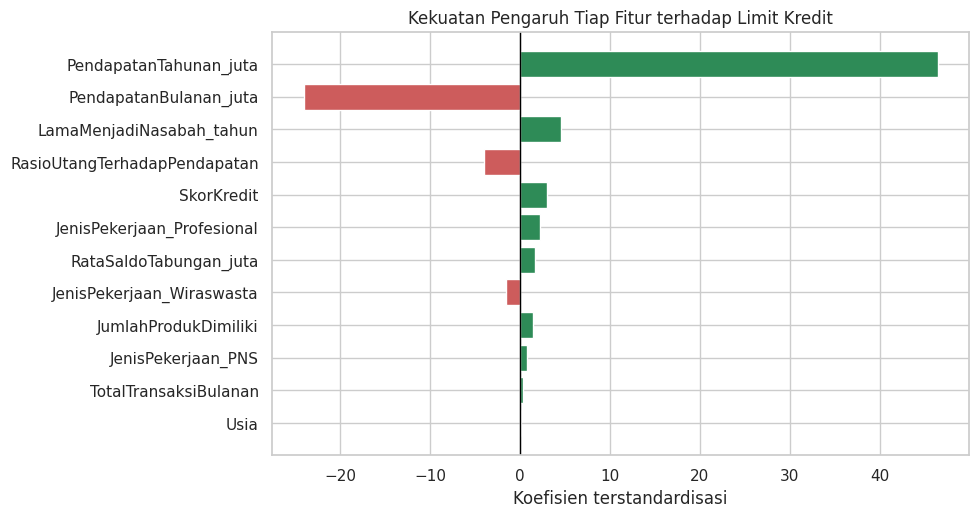

,fitur,koefisien_mentah,koefisien_terstandardisasi
2,PendapatanTahunan_juta,0.6127,46.4583
1,PendapatanBulanan_juta,-3.8073,-24.0570
4,LamaMenjadiNasabah_tahun,0.8208,4.6231
8,RasioUtangTerhadapPendapatan,-41.2077,-3.9839
3,SkorKredit,0.0515,3.0630
10,JenisPekerjaan_Profesional,6.6219,2.2901
5,RataSaldoTabungan_juta,0.0881,1.6779
11,JenisPekerjaan_Wiraswasta,-3.8241,-1.5454
6,JumlahProdukDimiliki,1.3578,1.5112
9,JenisPekerjaan_PNS,2.1088,0.8368


In [191]:
scaler_std = StandardScaler().fit(X_train)
model_std = LinearRegression().fit(scaler_std.transform(X_train), y_train)

kontribusi = pd.DataFrame({
    'fitur': X_train.columns,
    'koefisien_mentah': model_multi.coef_,
    'koefisien_terstandardisasi': model_std.coef_,
}).sort_values('koefisien_terstandardisasi', key=abs, ascending=False)

plt.figure(figsize=(9, 5.5))
warna = ['seagreen' if v > 0 else 'indianred' for v in kontribusi['koefisien_terstandardisasi']]
plt.barh(kontribusi['fitur'], kontribusi['koefisien_terstandardisasi'], color=warna)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Koefisien terstandardisasi')
plt.title('Kekuatan Pengaruh Tiap Fitur terhadap Limit Kredit')
plt.gca().invert_yaxis()
plt.show()

kontribusi.round(4)

Grafik ini adalah bentuk paling siap pakai untuk dipresentasikan ke pemilik bisnis. Batang hijau menaikkan limit, batang merah menurunkannya, dan panjang batang menunjukkan besar pengaruh setelah perbedaan satuan dihilangkan.

Meski begitu, ada satu keanehan yang belum bisa kita jelaskan. Dua fitur pendapatan menunjukkan koefisien yang besar dengan arah berlawanan, padahal keduanya semestinya sama-sama menaikkan limit. Kita bongkar penyebabnya sekarang.

---

# Bagian 6: Multicollinearity

## 6.1 Definisi dan Akibatnya

**Multikolinearitas** terjadi ketika dua atau lebih fitur saling berkorelasi kuat, sehingga informasi yang dibawa salah satu fitur sudah hampir seluruhnya terkandung di fitur lain.

Kenapa ini bermasalah. Ingat kembali rumus OLS, $\beta = (X^\top X)^{-1} X^\top y$. Ketika dua kolom hampir identik, matriks $X^\top X$ menjadi mendekati **singular**, artinya nyaris tidak punya invers. Sedikit saja perubahan pada data akan menghasilkan invers yang jauh berbeda, dan koefisien pun berayun liar.

Akibat yang muncul.

1. **Koefisien tidak stabil.** Nilainya berubah drastis bila sedikit data diubah atau dibuang.
2. **Tanda koefisien bisa terbalik.** Fitur yang logikanya positif malah bernilai negatif.
3. **Standard error membengkak.** Fitur yang sebenarnya penting jadi terlihat tidak signifikan.
4. **Interpretasi runtuh.** Klausa "fitur lain ditahan tetap" tidak lagi masuk akal, karena mustahil menaikkan pendapatan bulanan tanpa menaikkan pendapatan tahunan.

Satu catatan penting yang sering disalahpahami. Multikolinearitas **tidak selalu merusak akurasi prediksi**. Kalau tujuan kita murni memprediksi, model bisa saja tetap akurat. Masalah besarnya ada pada **interpretasi**, dan di perbankan interpretasi itu wajib karena model harus lolos validasi serta dapat dipertanggungjawabkan ke regulator.

## 6.2 Cara Mendeteksi

**Langkah pertama, matriks korelasi.** Cepat, tetapi hanya menangkap hubungan antar dua fitur.

In [192]:
corr_fitur = X_train.corr().abs()
mask_atas = np.triu(np.ones_like(corr_fitur, dtype=bool))

pasangan = (
    corr_fitur.where(~mask_atas)
    .stack()
    .reset_index()
)
pasangan.columns = ['fitur_1', 'fitur_2', 'korelasi_absolut']
pasangan = pasangan.sort_values('korelasi_absolut', ascending=False)

print('Pasangan fitur dengan korelasi tertinggi:')
display(pasangan.head(8).round(4))

print('\nPasangan dengan korelasi absolut di atas 0.8 (ambang kewaspadaan):')
display(pasangan[pasangan['korelasi_absolut'] > 0.8].round(4))

Pasangan fitur dengan korelasi tertinggi:


,fitur_1,fitur_2,korelasi_absolut
2,PendapatanTahunan_juta,PendapatanBulanan_juta,1.0000
12,RataSaldoTabungan_juta,PendapatanTahunan_juta,0.6565
11,RataSaldoTabungan_juta,PendapatanBulanan_juta,0.6564
22,TotalTransaksiBulanan,PendapatanBulanan_juta,0.4550
23,TotalTransaksiBulanan,PendapatanTahunan_juta,0.4548
27,TotalTransaksiBulanan,JumlahProdukDimiliki,0.3531
16,JumlahProdukDimiliki,PendapatanBulanan_juta,0.3399
17,JumlahProdukDimiliki,PendapatanTahunan_juta,0.3398



Pasangan dengan korelasi absolut di atas 0.8 (ambang kewaspadaan):


,fitur_1,fitur_2,korelasi_absolut
2,PendapatanTahunan_juta,PendapatanBulanan_juta,1.0


**Langkah kedua, Variance Inflation Factor (VIF).** Ini alat yang lebih tajam karena mendeteksi kolinearitas yang melibatkan **tiga fitur atau lebih**, sesuatu yang tidak terlihat pada matriks korelasi biasa.

Untuk fitur ke-$j$, kita regresikan fitur itu terhadap seluruh fitur lain, ambil $R^2_j$-nya, lalu hitung

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

Ambang yang lazim dipakai di industri.

| Nilai VIF | Tafsiran |
|-----------|----------|
| 1 | Sama sekali tidak berkorelasi dengan fitur lain |
| 1 sampai 5 | Aman |
| 5 sampai 10 | Perlu diwaspadai |
| Di atas 10 | Multikolinearitas serius, harus ditangani |

In [193]:
def hitung_vif(X_df):
    Xc = sm.add_constant(X_df.astype(float))
    hasil = pd.DataFrame({
        'fitur': Xc.columns,
        'VIF': [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])],
    })
    hasil = hasil[hasil['fitur'] != 'const'].copy()
    hasil['status'] = pd.cut(
        hasil['VIF'],
        bins=[0, 5, 10, np.inf],
        labels=['aman', 'waspada', 'bermasalah'],
    )
    return hasil.sort_values('VIF', ascending=False).reset_index(drop=True)


vif_awal = hitung_vif(X_train)
vif_awal.round(2)

,fitur,VIF,status
0,PendapatanBulanan_juta,14238.08,bermasalah
1,PendapatanTahunan_juta,14235.79,bermasalah
2,RataSaldoTabungan_juta,1.77,aman
3,TotalTransaksiBulanan,1.35,aman
4,JumlahProdukDimiliki,1.21,aman
5,JenisPekerjaan_Wiraswasta,1.16,aman
6,JenisPekerjaan_PNS,1.15,aman
7,SkorKredit,1.15,aman
8,JenisPekerjaan_Profesional,1.13,aman
9,LamaMenjadiNasabah_tahun,1.09,aman


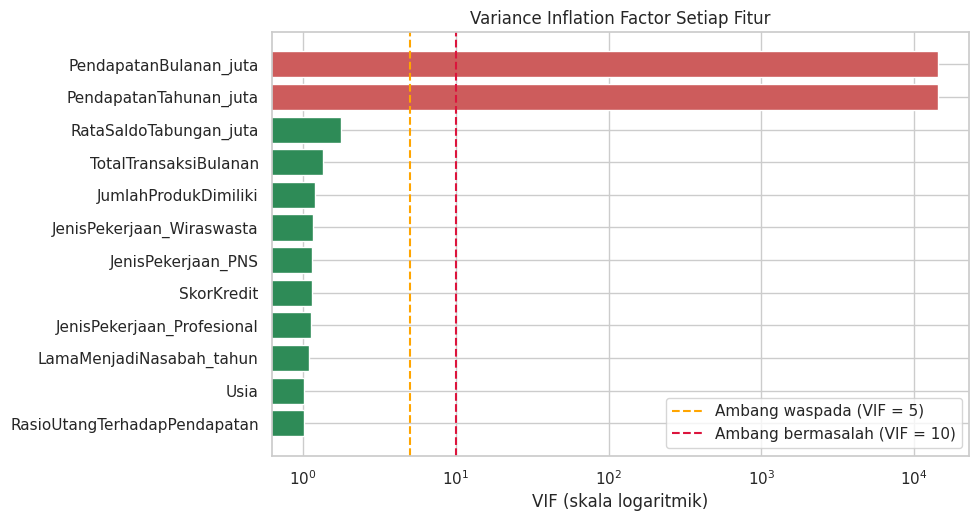

In [194]:
plt.figure(figsize=(9, 5.5))
warna_vif = ['indianred' if v > 10 else ('orange' if v > 5 else 'seagreen')
             for v in vif_awal['VIF']]
plt.barh(vif_awal['fitur'], vif_awal['VIF'], color=warna_vif)
plt.axvline(5, color='orange', linestyle='--', label='Ambang waspada (VIF = 5)')
plt.axvline(10, color='crimson', linestyle='--', label='Ambang bermasalah (VIF = 10)')
plt.xscale('log')
plt.xlabel('VIF (skala logaritmik)')
plt.title('Variance Inflation Factor Setiap Fitur')
plt.legend()
plt.gca().invert_yaxis()
plt.show()

## 6.3 Membuktikan Ketidakstabilan Koefisien

Teori sudah, sekarang buktinya. Kita ambil beberapa sampel *bootstrap* dari data latih, melatih ulang model pada masing-masing sampel, lalu melihat seberapa jauh koefisien berayun. Fitur yang bermasalah akan menunjukkan ayunan yang jauh lebih lebar dibanding fitur yang sehat.

In [195]:
rng_boot = np.random.default_rng(RANDOM_STATE)
koef_bootstrap = []

for _ in range(200):
    idx = rng_boot.choice(len(X_train), size=len(X_train), replace=True)
    m = LinearRegression().fit(X_train.iloc[idx], y_train.iloc[idx])
    koef_bootstrap.append(m.coef_)

koef_bootstrap = pd.DataFrame(koef_bootstrap, columns=X_train.columns)

stabilitas = pd.DataFrame({
    'fitur': X_train.columns,
    'koef_rata2': koef_bootstrap.mean(),
    'koef_std': koef_bootstrap.std(),
    'koef_min': koef_bootstrap.min(),
    'koef_maks': koef_bootstrap.max(),
}).reset_index(drop=True)
stabilitas['rentang'] = stabilitas['koef_maks'] - stabilitas['koef_min']
stabilitas['ganti_tanda'] = np.where(
    (stabilitas['koef_min'] < 0) & (stabilitas['koef_maks'] > 0), 'YA', 'tidak'
)
stabilitas.sort_values('rentang', ascending=False).round(3)

,fitur,koef_rata2,koef_std,koef_min,koef_maks,rentang,ganti_tanda
1,PendapatanBulanan_juta,-3.160,7.084,-25.163,17.683,42.846,YA
8,RasioUtangTerhadapPendapatan,-41.312,2.672,-47.426,-34.459,12.967,tidak
2,PendapatanTahunan_juta,0.557,0.601,-1.210,2.414,3.624,YA
11,JenisPekerjaan_Wiraswasta,-3.758,0.587,-5.477,-2.024,3.453,tidak
9,JenisPekerjaan_PNS,2.172,0.633,0.437,3.664,3.227,tidak
10,JenisPekerjaan_Profesional,6.746,0.649,5.144,8.212,3.068,tidak
6,JumlahProdukDimiliki,1.363,0.326,0.420,2.083,1.663,tidak
4,LamaMenjadiNasabah_tahun,0.822,0.043,0.714,0.957,0.243,tidak
5,RataSaldoTabungan_juta,0.090,0.035,0.004,0.185,0.180,tidak
7,TotalTransaksiBulanan,0.030,0.019,-0.020,0.102,0.123,YA


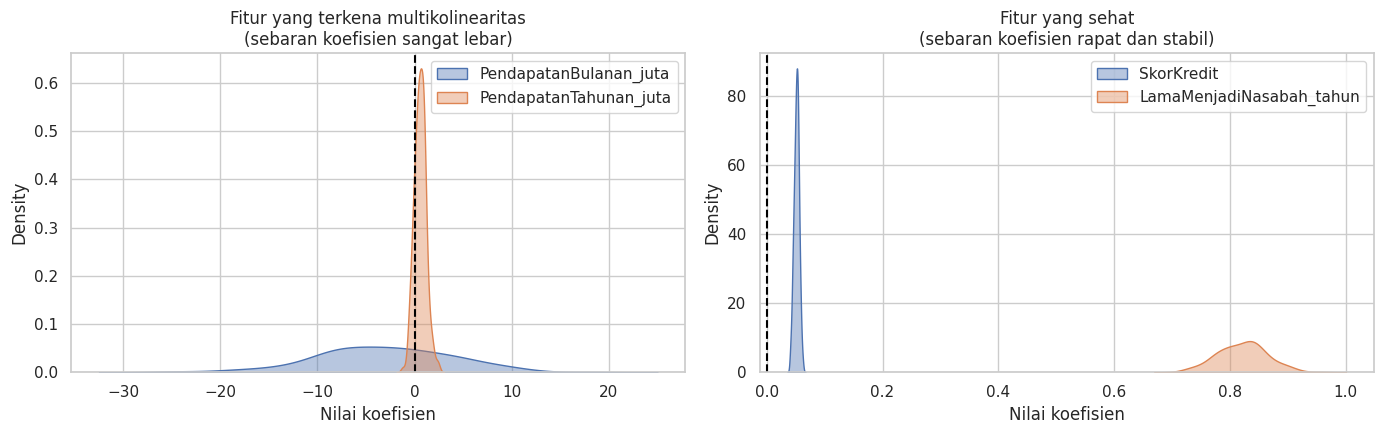

In [196]:
fitur_masalah = ['PendapatanBulanan_juta', 'PendapatanTahunan_juta']
fitur_sehat = ['SkorKredit', 'LamaMenjadiNasabah_tahun']

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for f in fitur_masalah:
    sns.kdeplot(koef_bootstrap[f], ax=axes[0], fill=True, alpha=0.4, label=f)
axes[0].axvline(0, color='black', linestyle='--')
axes[0].set_title('Fitur yang terkena multikolinearitas\n(sebaran koefisien sangat lebar)')
axes[0].set_xlabel('Nilai koefisien')
axes[0].legend()

for f in fitur_sehat:
    sns.kdeplot(koef_bootstrap[f], ax=axes[1], fill=True, alpha=0.4, label=f)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Fitur yang sehat\n(sebaran koefisien rapat dan stabil)')
axes[1].set_xlabel('Nilai koefisien')
axes[1].legend()

plt.tight_layout()
plt.show()

Perbedaannya kentara. Koefisien kedua fitur pendapatan menyebar sangat lebar dan bahkan melewati angka nol, artinya tandanya bisa positif atau negatif tergantung sampel mana yang kebetulan terambil. Model seperti ini tidak akan lolos tahap *model validation*, karena kita tidak bisa menjelaskan arah pengaruh pendapatan dengan yakin.

## 6.4 Penanganan

Ada empat pendekatan yang lazim dipakai.

1. **Buang salah satu fitur.** Paling sederhana dan paling sering benar ketika dua fitur memang mengukur hal yang sama.
2. **Gabungkan menjadi satu fitur baru.** Misalnya membuat rasio atau indeks komposit dari beberapa fitur yang berkaitan.
3. **Pakai regularisasi Ridge.** Penalti L2 mengecilkan koefisien dan membuatnya stabil meski fitur berkorelasi.
4. **Pakai PCA.** Komponen utama saling ortogonal sehingga bebas kolinearitas, tetapi interpretasinya menjadi jauh lebih sulit.

Kita coba opsi pertama dan ketiga.

In [197]:
X_train_bersih = X_train.drop(columns=['PendapatanTahunan_juta'])
X_test_bersih = X_test.drop(columns=['PendapatanTahunan_juta'])

vif_bersih = hitung_vif(X_train_bersih)
print('VIF setelah PendapatanTahunan_juta dibuang:')
display(vif_bersih.round(2))

model_bersih = LinearRegression().fit(X_train_bersih, y_train)
pred_bersih = model_bersih.predict(X_test_bersih)

print('\n=== PERBANDINGAN SEBELUM DAN SESUDAH PENANGANAN ===')
print(f"{'':<28}{'RMSE test':>12}{'R2 test':>12}{'VIF maks':>12}")
print('-' * 64)
print(f"{'Semua fitur':<28}"
      f"{np.sqrt(mean_squared_error(y_test, pred_test)):>12.3f}"
      f"{r2_score(y_test, pred_test):>12.4f}"
      f"{vif_awal['VIF'].max():>12.1f}")
print(f"{'Tanpa PendapatanTahunan':<28}"
      f"{np.sqrt(mean_squared_error(y_test, pred_bersih)):>12.3f}"
      f"{r2_score(y_test, pred_bersih):>12.4f}"
      f"{vif_bersih['VIF'].max():>12.1f}")

VIF setelah PendapatanTahunan_juta dibuang:


,fitur,VIF,status
0,PendapatanBulanan_juta,2.18,aman
1,RataSaldoTabungan_juta,1.77,aman
2,TotalTransaksiBulanan,1.35,aman
3,JumlahProdukDimiliki,1.21,aman
4,JenisPekerjaan_Wiraswasta,1.16,aman
5,JenisPekerjaan_PNS,1.15,aman
6,SkorKredit,1.14,aman
7,JenisPekerjaan_Profesional,1.13,aman
8,LamaMenjadiNasabah_tahun,1.09,aman
9,Usia,1.02,aman



=== PERBANDINGAN SEBELUM DAN SESUDAH PENANGANAN ===
                               RMSE test     R2 test    VIF maks
----------------------------------------------------------------
Semua fitur                        7.461      0.9406     14238.1
Tanpa PendapatanTahunan            7.400      0.9416         2.2


In [198]:
koef_banding = pd.DataFrame({
    'fitur': X_train_bersih.columns,
    'koef_sebelum': [model_multi.coef_[list(X_train.columns).index(c)]
                     for c in X_train_bersih.columns],
    'koef_sesudah': model_bersih.coef_,
}).round(4)
koef_banding['perubahan'] = (koef_banding['koef_sesudah'] - koef_banding['koef_sebelum']).round(4)
print('Koefisien PendapatanBulanan_juta kembali masuk akal dan stabil setelah kembarannya dibuang.')
koef_banding

Koefisien PendapatanBulanan_juta kembali masuk akal dan stabil setelah kembarannya dibuang.


,fitur,koef_sebelum,koef_sesudah,perubahan
0,Usia,0.0085,0.0081,-0.0004
1,PendapatanBulanan_juta,-3.8073,3.5453,7.3526
2,SkorKredit,0.0515,0.0511,-0.0004
3,LamaMenjadiNasabah_tahun,0.8208,0.8227,0.0019
4,RataSaldoTabungan_juta,0.0881,0.0888,0.0007
5,JumlahProdukDimiliki,1.3578,1.3565,-0.0013
6,TotalTransaksiBulanan,0.0301,0.0292,-0.0009
7,RasioUtangTerhadapPendapatan,-41.2077,-41.3139,-0.1062
8,JenisPekerjaan_PNS,2.1088,2.1165,0.0077
9,JenisPekerjaan_Profesional,6.6219,6.6339,0.0120


In [199]:
alphas = [0.01, 0.1, 1, 10, 100, 500]
baris_ridge = []

for a in alphas:
    pipe_r = make_pipeline(StandardScaler(), Ridge(alpha=a))
    pipe_r.fit(X_train, y_train)
    koef_r = pipe_r.named_steps['ridge'].coef_
    idx_bln = list(X_train.columns).index('PendapatanBulanan_juta')
    idx_thn = list(X_train.columns).index('PendapatanTahunan_juta')
    baris_ridge.append({
        'alpha': a,
        'koef_PendapatanBulanan': round(koef_r[idx_bln], 3),
        'koef_PendapatanTahunan': round(koef_r[idx_thn], 3),
        'RMSE_test': round(np.sqrt(mean_squared_error(y_test, pipe_r.predict(X_test))), 3),
    })

print('Efek regularisasi Ridge terhadap pasangan fitur yang kolinear:')
print('(koefisien di sini memakai fitur terstandardisasi)')
pd.DataFrame(baris_ridge)

Efek regularisasi Ridge terhadap pasangan fitur yang kolinear:
(koefisien di sini memakai fitur terstandardisasi)


,alpha,koef_PendapatanBulanan,koef_PendapatanTahunan,RMSE_test
0,0.01,-14.065,36.467,7.446
1,0.10,4.083,18.317,7.422
2,1.00,10.317,12.058,7.414
3,10.00,10.971,11.151,7.412
4,100.00,10.029,10.048,7.674
5,500.00,7.649,7.654,10.304


Semakin besar `alpha`, koefisien kedua fitur pendapatan makin mengecil dan makin dekat satu sama lain. Ridge tidak menghapus salah satu fitur, melainkan **membagi pengaruh** di antara keduanya secara lebih merata sehingga hasilnya jauh lebih stabil.

Untuk keperluan lab ini, kita lanjutkan dengan pendekatan paling sederhana, yaitu membuang `PendapatanTahunan_juta`.

---

# Bagian 7: Overfitting

## 7.1 Bias, Variance, dan Titik Tengahnya

**Overfitting** terjadi ketika model menghafal data latih, termasuk derau di dalamnya, sehingga gagal bekerja pada data baru. Lawannya adalah **underfitting**, yaitu model yang terlalu sederhana sehingga tidak menangkap pola apa pun.

| Kondisi | Galat data latih | Galat data uji | Diagnosis |
|---------|------------------|----------------|-----------|
| Underfitting | Tinggi | Tinggi | Bias tinggi, model terlalu sederhana |
| Pas | Rendah | Rendah | Kondisi yang kita cari |
| Overfitting | Sangat rendah | Tinggi | Variance tinggi, model terlalu rumit |

Total galat sebuah model dapat dipecah menjadi tiga bagian.

$$\text{Galat} = \text{Bias}^2 + \text{Variance} + \text{Galat tak tereduksi}$$

Menambah kerumitan model menurunkan bias tetapi menaikkan variance. Tugas kita adalah mencari titik seimbang di antara keduanya.

## 7.2 Gejala Pertama: Selisih Performa Latih dan Uji

Model linear kita sekarang justru cenderung *underfit*, dan itu wajar karena model ini memang sederhana. Untuk melihat overfitting dengan jelas, kita perlu sengaja menaikkan kerumitan model, dan cara termudah adalah menambahkan suku polinomial berderajat tinggi.

In [200]:
hasil_derajat = []

for derajat in range(1, 7):
    pipe = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=derajat, include_bias=False),
        LinearRegression(),
    )
    pipe.fit(X_train_bersih, y_train)

    rmse_tr = np.sqrt(mean_squared_error(y_train, pipe.predict(X_train_bersih)))
    rmse_te = np.sqrt(mean_squared_error(y_test, pipe.predict(X_test_bersih)))
    n_fitur_baru = pipe.named_steps['polynomialfeatures'].n_output_features_

    hasil_derajat.append({
        'derajat': derajat,
        'jumlah_fitur': n_fitur_baru,
        'RMSE_latih': round(rmse_tr, 3),
        'RMSE_uji': round(rmse_te, 3),
        'selisih': round(rmse_te - rmse_tr, 3),
    })
    if derajat >= 4 and rmse_te > 1e3:
        break

df_derajat = pd.DataFrame(hasil_derajat)
df_derajat

,derajat,jumlah_fitur,RMSE_latih,RMSE_uji,selisih
0,1,11,6.347,7.400,1.053
1,2,77,4.786,5.114,0.329
2,3,363,3.859,7.937,4.078
3,4,1364,0.000,318.492,318.492
4,5,4367,0.000,159.469,159.469
5,6,12375,0.000,553.599,553.599


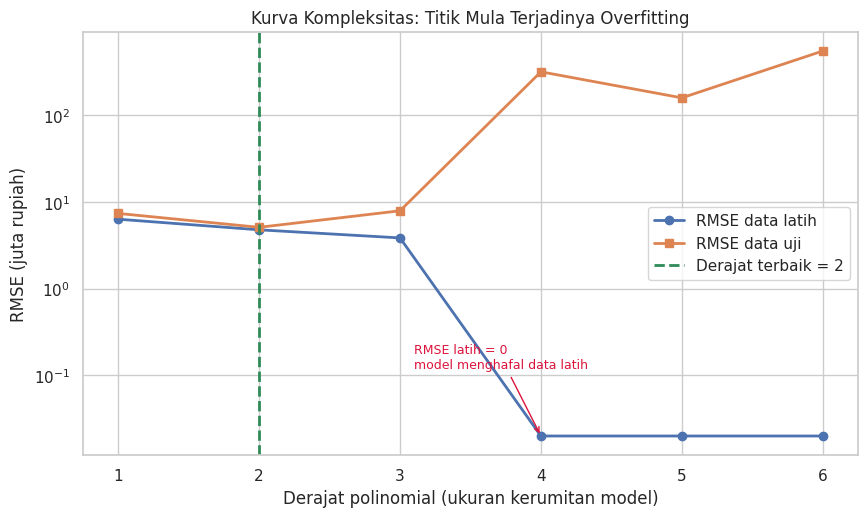

Cara membaca grafik:
  Sisi kiri  : kedua garis sama-sama tinggi, model underfitting.
  Garis hijau: galat data uji paling rendah, inilah kerumitan yang pas.
  Sisi kanan : galat latih jatuh sampai nol tetapi galat uji melonjak,
               inilah overfitting dalam bentuk paling ekstrem.


In [201]:
# Sumbu y memakai skala logaritmik, sedangkan RMSE latih bisa persis nol pada
# derajat tinggi. Nilai nol diberi lantai kecil supaya titiknya tetap tergambar.
LANTAI = 0.02
rmse_latih_plot = df_derajat['RMSE_latih'].clip(lower=LANTAI)

plt.figure(figsize=(10, 5.5))
plt.plot(df_derajat['derajat'], rmse_latih_plot,
         marker='o', linewidth=2, label='RMSE data latih')
plt.plot(df_derajat['derajat'], df_derajat['RMSE_uji'],
         marker='s', linewidth=2, label='RMSE data uji')

d_terbaik = df_derajat.loc[df_derajat['RMSE_uji'].idxmin(), 'derajat']
plt.axvline(d_terbaik, color='seagreen', linestyle='--', linewidth=2,
            label=f'Derajat terbaik = {d_terbaik}')

hafal = df_derajat[df_derajat['RMSE_latih'] == 0]
if not hafal.empty:
    plt.annotate('RMSE latih = 0\nmodel menghafal data latih',
                 xy=(hafal['derajat'].iloc[0], LANTAI),
                 xytext=(hafal['derajat'].iloc[0] - 0.9, LANTAI * 6),
                 arrowprops=dict(arrowstyle='->', color='crimson'),
                 color='crimson', fontsize=9)

plt.xlabel('Derajat polinomial (ukuran kerumitan model)')
plt.ylabel('RMSE (juta rupiah)')
plt.title('Kurva Kompleksitas: Titik Mula Terjadinya Overfitting')
plt.yscale('log')
plt.legend()
plt.xticks(df_derajat['derajat'])
plt.show()

print('Cara membaca grafik:')
print('  Sisi kiri  : kedua garis sama-sama tinggi, model underfitting.')
print('  Garis hijau: galat data uji paling rendah, inilah kerumitan yang pas.')
print('  Sisi kanan : galat latih jatuh sampai nol tetapi galat uji melonjak,')
print('               inilah overfitting dalam bentuk paling ekstrem.')

## 7.3 Gejala Kedua: Learning Curve

*Learning curve* menunjukkan bagaimana performa berubah seiring bertambahnya jumlah data latih. Grafik ini membantu menjawab satu pertanyaan yang sangat praktis, yaitu apakah menambah data akan menolong atau tidak.

- **Kedua kurva bertemu di posisi galat tinggi.** Model underfitting. Menambah data tidak akan menolong, yang dibutuhkan adalah model yang lebih kaya atau fitur yang lebih baik.
- **Ada jurang lebar antara kedua kurva.** Model overfitting. Menambah data atau menambah regularisasi kemungkinan besar menolong.

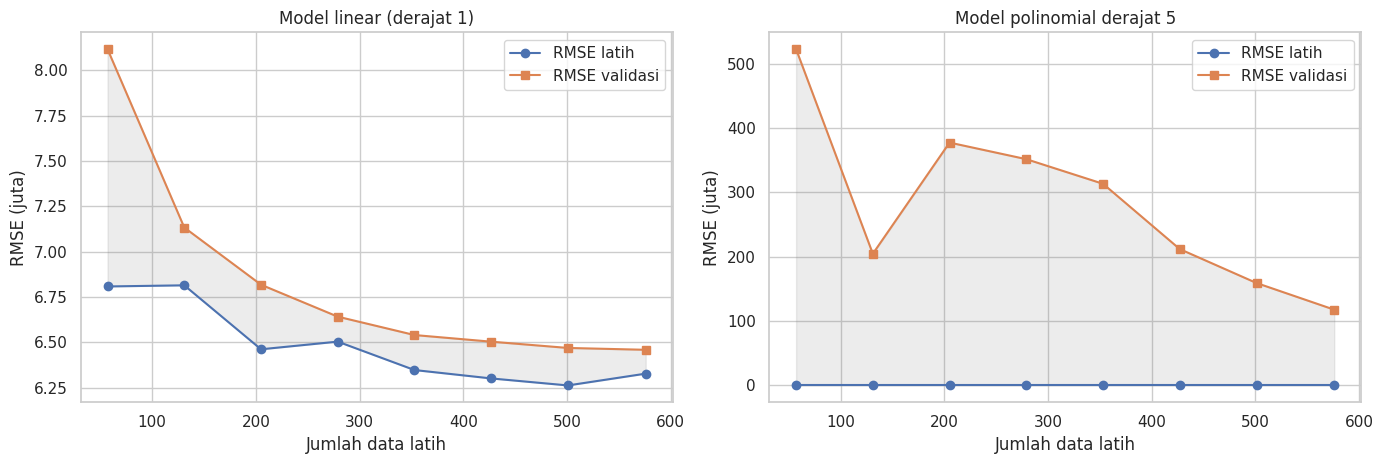

Area abu-abu adalah jurang antara performa latih dan validasi.
Jurang yang lebar dan tidak menyempit adalah tanda overfitting.


In [150]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

konfigurasi = [
    ('Model linear (derajat 1)',
     make_pipeline(StandardScaler(), LinearRegression())),
    ('Model polinomial derajat 5',
     make_pipeline(StandardScaler(), PolynomialFeatures(5, include_bias=False),
                   LinearRegression())),
]

for ax, (judul, estimator) in zip(axes, konfigurasi):
    ukuran, skor_tr, skor_va = learning_curve(
        estimator, X_train_bersih, y_train,
        train_sizes=np.linspace(0.1, 1.0, 8),
        cv=5, scoring='neg_root_mean_squared_error', random_state=RANDOM_STATE,
    )
    rmse_tr = -skor_tr.mean(axis=1)
    rmse_va = -skor_va.mean(axis=1)

    ax.plot(ukuran, rmse_tr, marker='o', label='RMSE latih')
    ax.plot(ukuran, rmse_va, marker='s', label='RMSE validasi')
    ax.fill_between(ukuran, rmse_tr, rmse_va, alpha=0.15, color='gray')
    ax.set_xlabel('Jumlah data latih')
    ax.set_ylabel('RMSE (juta)')
    ax.set_title(judul)
    ax.legend()

plt.tight_layout()
plt.show()

print('Area abu-abu adalah jurang antara performa latih dan validasi.')
print('Jurang yang lebar dan tidak menyempit adalah tanda overfitting.')

## 7.4 Cara Mencegah Overfitting

1. **Cross validation.** Jangan pernah menilai model dari satu kali pembagian data saja.
2. **Regularisasi.** Ridge (penalti L2) mengecilkan seluruh koefisien, Lasso (penalti L1) bahkan bisa menihilkan koefisien fitur yang tidak berguna.
3. **Kurangi fitur.** Buang fitur yang tidak signifikan atau yang saling tumpang tindih.
4. **Tambah data.** Efektif bila masalahnya memang variance tinggi.
5. **Sederhanakan model.** Turunkan derajat polinomial atau kurangi suku interaksi.

In [151]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

model_uji = {
    'Linear (derajat 1)': make_pipeline(StandardScaler(), LinearRegression()),
    'Polinomial derajat 2': make_pipeline(
        StandardScaler(), PolynomialFeatures(2, include_bias=False), LinearRegression()),
    'Polinomial derajat 5': make_pipeline(
        StandardScaler(), PolynomialFeatures(5, include_bias=False), LinearRegression()),
    'Polinomial derajat 2 + Ridge': make_pipeline(
        StandardScaler(), PolynomialFeatures(2, include_bias=False), Ridge(alpha=10)),
    'Polinomial derajat 5 + Ridge': make_pipeline(
        StandardScaler(), PolynomialFeatures(5, include_bias=False), Ridge(alpha=100)),
}

baris_cv = []
for nama, est in model_uji.items():
    skor = cross_val_score(est, X_train_bersih, y_train, cv=kf,
                           scoring='neg_root_mean_squared_error')
    est.fit(X_train_bersih, y_train)
    baris_cv.append({
        'model': nama,
        'RMSE_cv_rata2': round(-skor.mean(), 3),
        'RMSE_cv_std': round(skor.std(), 3),
        'RMSE_test': round(np.sqrt(mean_squared_error(y_test, est.predict(X_test_bersih))), 3),
    })

pd.DataFrame(baris_cv).sort_values('RMSE_cv_rata2')

,model,RMSE_cv_rata2,RMSE_cv_std,RMSE_test
1,Polinomial derajat 2,5.387,0.358,5.114
3,Polinomial derajat 2 + Ridge,5.401,0.330,5.053
0,Linear (derajat 1),6.483,1.074,7.400
4,Polinomial derajat 5 + Ridge,49.996,33.223,345.627
2,Polinomial derajat 5,142.902,147.823,159.469


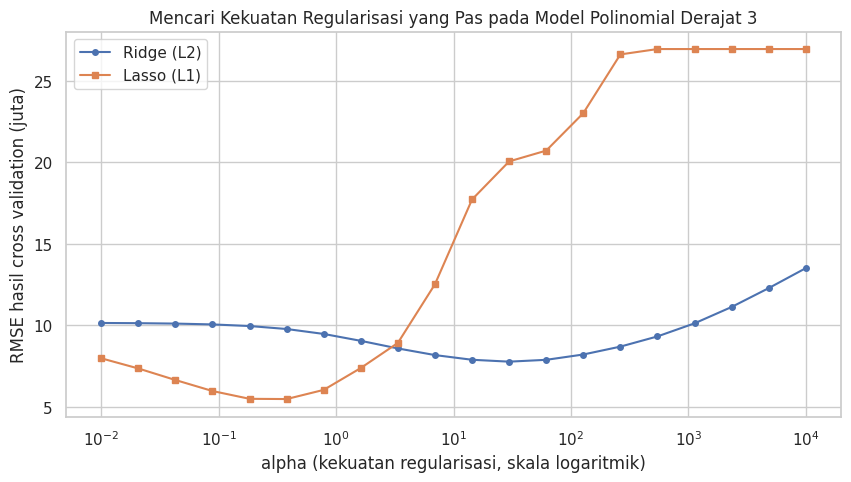

Alpha terbaik Ridge : 29.7635 (RMSE cv 7.770)
Alpha terbaik Lasso : 0.3793 (RMSE cv 5.477)

Alpha terlalu kecil membuat model bebas dan mudah overfit.
Alpha terlalu besar memaksa koefisien mendekati nol sehingga model jadi underfit.


In [152]:
alphas = np.logspace(-2, 4, 20)
rmse_ridge, rmse_lasso = [], []

for a in alphas:
    pr = make_pipeline(StandardScaler(), PolynomialFeatures(3, include_bias=False), Ridge(alpha=a))
    pl = make_pipeline(StandardScaler(), PolynomialFeatures(3, include_bias=False),
                       Lasso(alpha=a, max_iter=5000))
    rmse_ridge.append(-cross_val_score(pr, X_train_bersih, y_train, cv=kf,
                                       scoring='neg_root_mean_squared_error').mean())
    rmse_lasso.append(-cross_val_score(pl, X_train_bersih, y_train, cv=kf,
                                       scoring='neg_root_mean_squared_error').mean())

plt.figure(figsize=(10, 5))
plt.plot(alphas, rmse_ridge, marker='o', markersize=4, label='Ridge (L2)')
plt.plot(alphas, rmse_lasso, marker='s', markersize=4, label='Lasso (L1)')
plt.xscale('log')
plt.xlabel('alpha (kekuatan regularisasi, skala logaritmik)')
plt.ylabel('RMSE hasil cross validation (juta)')
plt.title('Mencari Kekuatan Regularisasi yang Pas pada Model Polinomial Derajat 3')
plt.legend()
plt.show()

print(f'Alpha terbaik Ridge : {alphas[int(np.argmin(rmse_ridge))]:.4f} '
      f'(RMSE cv {min(rmse_ridge):.3f})')
print(f'Alpha terbaik Lasso : {alphas[int(np.argmin(rmse_lasso))]:.4f} '
      f'(RMSE cv {min(rmse_lasso):.3f})')
print()
print('Alpha terlalu kecil membuat model bebas dan mudah overfit.')
print('Alpha terlalu besar memaksa koefisien mendekati nol sehingga model jadi underfit.')

> ### Giliran Anda (2 menit)
>
> Pada sweep alpha di atas, ganti `PolynomialFeatures(3, ...)` menjadi `PolynomialFeatures(2, ...)` lalu jalankan ulang.
>
> Amati apakah kurva RMSE-nya jadi lebih landai atau lebih curam. Model yang lebih sederhana biasanya kurang sensitif terhadap kekuatan regularisasi. Terlihatkah polanya.

---

# Bagian 8: Polynomial Regression

## 8.1 Tetap Linear, Meski Namanya Polinomial

*Polynomial regression* menambahkan pangkat dari fitur asli sebagai fitur baru.

$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + \dots + \beta_d x^d$$

Poin yang sering membingungkan dan penting diluruskan. Model ini **tetap tergolong linear**, karena yang dimaksud linear dalam istilah *linear model* adalah **linear terhadap koefisien $\beta$**, bukan linear terhadap $x$. Konsekuensinya menyenangkan, kita masih bisa memakai OLS yang sama persis, cukup dengan mengganti matriks fitur $X$ menjadi versi yang sudah diperluas.

Untuk beberapa fitur sekaligus, `PolynomialFeatures` juga membangkitkan **suku interaksi**. Contohnya, dari dua fitur $x_1$ dan $x_2$ pada derajat 2 akan lahir $x_1$, $x_2$, $x_1^2$, $x_1 x_2$, dan $x_2^2$. Suku $x_1 x_2$ inilah yang memungkinkan model menangkap gagasan bahwa pengaruh satu fitur bergantung pada nilai fitur lain.

In [153]:
contoh_pf = PolynomialFeatures(degree=2, include_bias=False)
contoh_pf.fit(X_train_bersih[['PendapatanBulanan_juta', 'SkorKredit']])

print('Dari 2 fitur asli, PolynomialFeatures derajat 2 menghasilkan:')
for nama in contoh_pf.get_feature_names_out():
    print('  -', nama)

print()
for d in [1, 2, 3, 4]:
    pf = PolynomialFeatures(degree=d, include_bias=False)
    pf.fit(X_train_bersih)
    print(f'Derajat {d}: {X_train_bersih.shape[1]} fitur asli menjadi '
          f'{pf.n_output_features_} fitur')
print()
print('Perhatikan ledakan jumlah fitur. Inilah alasan derajat tinggi sangat rawan overfitting.')

Dari 2 fitur asli, PolynomialFeatures derajat 2 menghasilkan:
  - PendapatanBulanan_juta
  - SkorKredit
  - PendapatanBulanan_juta^2
  - PendapatanBulanan_juta SkorKredit
  - SkorKredit^2

Derajat 1: 11 fitur asli menjadi 11 fitur
Derajat 2: 11 fitur asli menjadi 77 fitur
Derajat 3: 11 fitur asli menjadi 363 fitur
Derajat 4: 11 fitur asli menjadi 1364 fitur

Perhatikan ledakan jumlah fitur. Inilah alasan derajat tinggi sangat rawan overfitting.


## 8.2 Melihat Efeknya pada Satu Fitur

Supaya bentuk kurvanya terlihat jelas, kita mulai dari satu fitur saja, yaitu `PendapatanBulanan_juta`. Ingat kembali Bagian 2, di mana titik-titik nasabah berpendapatan tinggi cenderung berada di atas garis lurus.

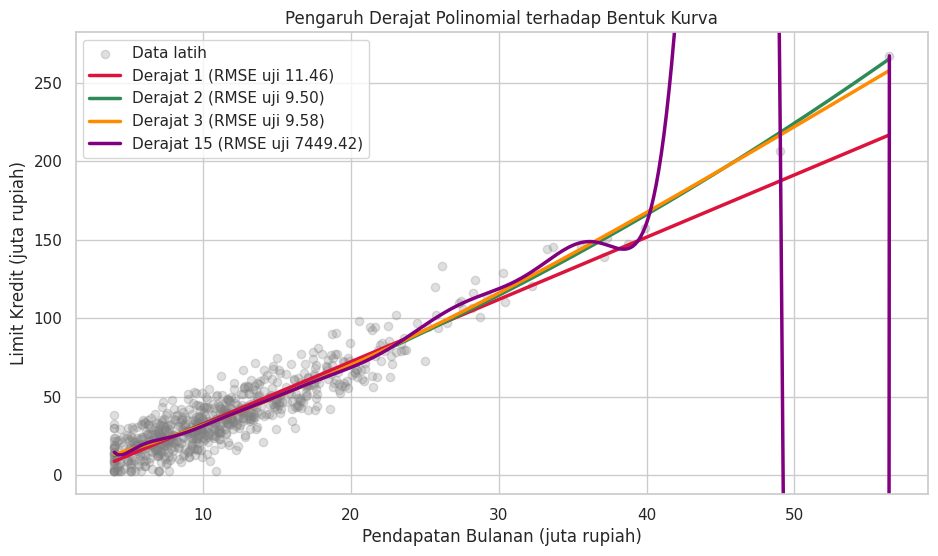

Derajat 1 (merah)  : garis lurus, gagal mengikuti kelengkungan di sisi kanan.
Derajat 2 (hijau)  : melengkung mengikuti pola data dengan wajar.
Derajat 3 (oranye) : mirip derajat 2, tambahan kerumitan tidak banyak membantu.
Derajat 15 (ungu)  : berkelok mengejar titik demi titik, inilah wajah overfitting.


In [154]:
x_satu = X_train_bersih[['PendapatanBulanan_juta']]
x_satu_test = X_test_bersih[['PendapatanBulanan_juta']]
grid = np.linspace(x_satu.values.min(), x_satu.values.max(), 300).reshape(-1, 1)
grid_df = pd.DataFrame(grid, columns=['PendapatanBulanan_juta'])

plt.figure(figsize=(11, 6))
plt.scatter(x_satu, y_train, alpha=0.25, color='gray', label='Data latih')

for d, warna in zip([1, 2, 3, 15], ['crimson', 'seagreen', 'darkorange', 'purple']):
    pipe = make_pipeline(PolynomialFeatures(d, include_bias=False),
                         StandardScaler(), LinearRegression())
    pipe.fit(x_satu, y_train)
    rmse_te = np.sqrt(mean_squared_error(y_test, pipe.predict(x_satu_test)))
    plt.plot(grid, pipe.predict(grid_df), linewidth=2.5, color=warna,
             label=f'Derajat {d} (RMSE uji {rmse_te:.2f})')

plt.xlabel('Pendapatan Bulanan (juta rupiah)')
plt.ylabel('Limit Kredit (juta rupiah)')
plt.title('Pengaruh Derajat Polinomial terhadap Bentuk Kurva')
plt.legend()
plt.ylim(y_train.min() - 15, y_train.max() + 15)
plt.show()

print('Derajat 1 (merah)  : garis lurus, gagal mengikuti kelengkungan di sisi kanan.')
print('Derajat 2 (hijau)  : melengkung mengikuti pola data dengan wajar.')
print('Derajat 3 (oranye) : mirip derajat 2, tambahan kerumitan tidak banyak membantu.')
print('Derajat 15 (ungu)  : berkelok mengejar titik demi titik, inilah wajah overfitting.')

## 8.3 Memilih Derajat dengan Cross Validation

Menentukan derajat berdasarkan performa data uji adalah kesalahan metodologis, karena data uji jadi ikut menentukan model dan tidak lagi netral. Cara yang benar adalah memilih derajat lewat **cross validation pada data latih**, lalu memakai data uji satu kali saja di paling akhir sebagai penilaian jujur.

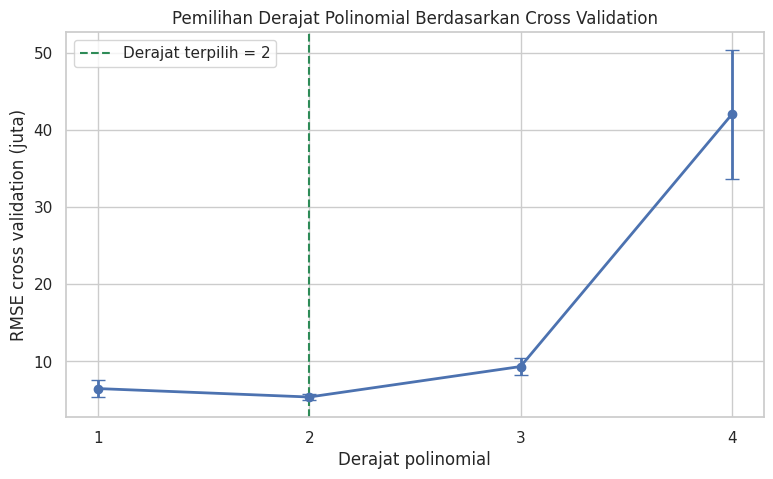

,derajat,jumlah_fitur,RMSE_cv_rata2,RMSE_cv_std
0,1,11,6.4820,1.0868
1,2,77,5.3844,0.3547
2,3,363,9.3405,1.0720
3,4,1364,42.0695,8.3749


In [155]:
derajat_uji = [1, 2, 3, 4]
hasil_cv_poly = []

for d in derajat_uji:
    pipe = make_pipeline(StandardScaler(),
                         PolynomialFeatures(d, include_bias=False),
                         Ridge(alpha=1.0))
    skor = cross_val_score(pipe, X_train_bersih, y_train, cv=kf,
                           scoring='neg_root_mean_squared_error')
    hasil_cv_poly.append({
        'derajat': d,
        'jumlah_fitur': PolynomialFeatures(d, include_bias=False)
                        .fit(X_train_bersih).n_output_features_,
        'RMSE_cv_rata2': round(-skor.mean(), 4),
        'RMSE_cv_std': round(skor.std(), 4),
    })

df_cv_poly = pd.DataFrame(hasil_cv_poly)
derajat_terpilih = int(df_cv_poly.loc[df_cv_poly['RMSE_cv_rata2'].idxmin(), 'derajat'])

plt.figure(figsize=(9, 5))
plt.errorbar(df_cv_poly['derajat'], df_cv_poly['RMSE_cv_rata2'],
             yerr=df_cv_poly['RMSE_cv_std'], marker='o', capsize=5, linewidth=2)
plt.axvline(derajat_terpilih, color='seagreen', linestyle='--',
            label=f'Derajat terpilih = {derajat_terpilih}')
plt.xlabel('Derajat polinomial')
plt.ylabel('RMSE cross validation (juta)')
plt.title('Pemilihan Derajat Polinomial Berdasarkan Cross Validation')
plt.xticks(derajat_uji)
plt.legend()
plt.show()

df_cv_poly

In [156]:
model_final = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(derajat_terpilih, include_bias=False),
    Ridge(alpha=1.0),
)
model_final.fit(X_train_bersih, y_train)

pred_final_train = model_final.predict(X_train_bersih)
pred_final_test = model_final.predict(X_test_bersih)

p_final = model_final.named_steps['polynomialfeatures'].n_output_features_

ringkasan_akhir = pd.DataFrame([
    evaluasi_regresi(y_test.values,
                     np.full(len(y_test), y_train.mean()), 0, 'Baseline rata-rata'),
    evaluasi_regresi(y_test.values,
                     model_simple.predict(X_test[['PendapatanBulanan_juta']].values),
                     1, 'Simple LR (1 fitur)'),
    evaluasi_regresi(y_test.values, pred_test, X_train.shape[1],
                     'Multiple LR (semua fitur)'),
    evaluasi_regresi(y_test.values, pred_bersih, X_train_bersih.shape[1],
                     'Multiple LR (tanpa kolinear)'),
    evaluasi_regresi(y_test.values, pipe_sgd.predict(X_test), X_train.shape[1],
                     'SGD + scaling'),
    evaluasi_regresi(y_test.values, pred_final_test, p_final,
                     f'Polinomial derajat {derajat_terpilih} + Ridge'),
])
ringkasan_akhir

,set,n,MAE,RMSE,MAPE_persen,R2,Adj_R2
0,Baseline rata-rata,180,18.494,30.634,87.70,-0.0008,-0.0008
1,Simple LR (1 fitur),180,8.604,11.410,36.13,0.8612,0.8604
2,Multiple LR (semua fitur),180,4.727,7.461,18.33,0.9406,0.9364
3,Multiple LR (tanpa kolinear),180,4.753,7.400,18.51,0.9416,0.9378
4,SGD + scaling,180,4.748,7.454,18.42,0.9407,0.9365
5,Polinomial derajat 2 + Ridge,180,3.977,5.103,15.61,0.9722,0.9513


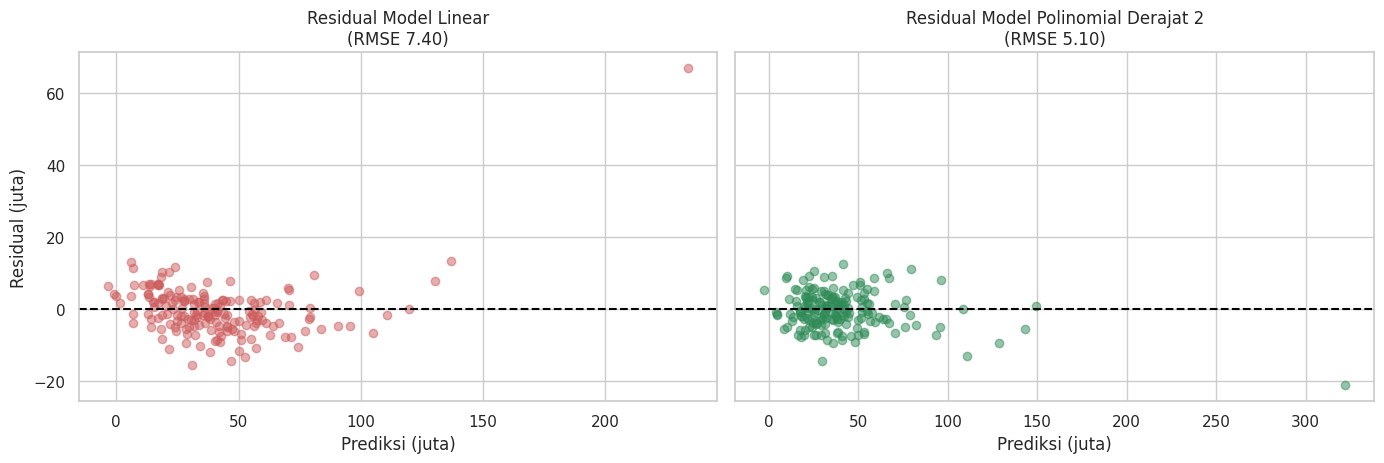

Lengkungan yang tadi terlihat pada residual model linear kini jauh berkurang.
Itulah bukti bahwa suku kuadratik memang dibutuhkan oleh data ini.


In [157]:
resid_linear = y_test.values - pred_bersih
resid_poly = y_test.values - pred_final_test

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)

ax[0].scatter(pred_bersih, resid_linear, alpha=0.5, color='indianred')
ax[0].axhline(0, color='black', linestyle='--')
ax[0].set_title(f'Residual Model Linear\n(RMSE {np.sqrt(mean_squared_error(y_test, pred_bersih)):.2f})')
ax[0].set_xlabel('Prediksi (juta)')
ax[0].set_ylabel('Residual (juta)')

ax[1].scatter(pred_final_test, resid_poly, alpha=0.5, color='seagreen')
ax[1].axhline(0, color='black', linestyle='--')
ax[1].set_title(f'Residual Model Polinomial Derajat {derajat_terpilih}\n'
                f'(RMSE {np.sqrt(mean_squared_error(y_test, pred_final_test)):.2f})')
ax[1].set_xlabel('Prediksi (juta)')

plt.tight_layout()
plt.show()

print('Lengkungan yang tadi terlihat pada residual model linear kini jauh berkurang.')
print('Itulah bukti bahwa suku kuadratik memang dibutuhkan oleh data ini.')

## 8.4 Hal yang Perlu Diwaspadai

1. **Interpretasi jadi rumit.** Setelah ada suku $x^2$, kita tidak bisa lagi berkata "naik satu satuan menaikkan target sekian" karena efeknya kini bergantung pada posisi $x$ itu sendiri.
2. **Ekstrapolasi berbahaya.** Kurva polinomial bisa melejit atau terjun bebas di luar rentang data latih. Jangan pakai model ini untuk nasabah dengan pendapatan jauh di luar rentang data historis.
3. **Multikolinearitas otomatis muncul.** Kolom $x$ dan $x^2$ pasti berkorelasi kuat. Karena itu penyekalaan dan regularisasi hampir selalu diperlukan.
4. **Cukup derajat rendah.** Pada kasus bisnis, derajat 2 atau 3 hampir selalu memadai. Derajat tinggi biasanya pertanda ada masalah lain pada data atau pemilihan fitur.

---

# Ringkasan Bagian Terpandu

| Topik | Inti yang perlu diingat |
|-------|------------------------|
| Intro to Regression | Regresi memprediksi angka kontinu. Selalu bangun baseline lebih dulu sebagai pembanding. |
| Linear Regression | OLS meminimalkan jumlah kuadrat galat. Solusinya punya bentuk tertutup $\beta = (X^\top X)^{-1} X^\top y$. |
| OLS vs SGD | OLS eksak dan langsung jadi, SGD iteratif tetapi terskala. SGD wajib memakai fitur yang sudah diskalakan. |
| Evaluasi dan interpretasi | Laporkan MAE, RMSE, dan $R^2$ sekaligus. Selalu periksa residual, jangan puas pada satu angka. |
| Multicollinearity | Deteksi dengan VIF. Merusak interpretasi, belum tentu merusak akurasi. |
| Overfitting | Kenali dari jurang antara galat latih dan uji. Tangani dengan cross validation dan regularisasi. |
| Polynomial Regression | Menangkap pola melengkung tanpa meninggalkan kerangka model linear. Pilih derajatnya lewat cross validation. |

**Alur kerja yang disarankan untuk kasus regresi di tempat kerja.**

1. Pahami dulu masalah bisnisnya dan tentukan apa yang sebenarnya ingin diprediksi.
2. Bangun baseline sederhana sebagai pembanding.
3. Latih model linear, periksa asumsinya lewat residual.
4. Diagnosis multikolinearitas dengan VIF, tangani bila ada yang di atas 10.
5. Evaluasi pada data uji, periksa jurang performa latih dan uji.
6. Naikkan kerumitan model secukupnya bila residual masih menunjukkan pola.
7. Terjemahkan hasilnya ke bahasa bisnis, lengkap dengan batasan dan asumsi model.

---

# Penutup: Dari Notebook ke Pekerjaan Sehari-hari

## Yang Sudah Anda Kerjakan Hari Ini

Anda membangun model regresi dari nol sampai jadi, lengkap dengan diagnosisnya. Bukan sekadar memanggil `.fit()`, tetapi memahami apa yang terjadi di baliknya.

| Yang dilakukan | Hasil akhir pada data uji |
|----------------|---------------------------|
| Baseline, selalu menebak rata-rata | RMSE sekitar 31 juta |
| Simple linear regression, satu fitur | RMSE sekitar 11 juta |
| Multiple linear regression | RMSE sekitar 7.5 juta |
| Setelah multikolinearitas ditangani | RMSE sekitar 7.4 juta, koefisien jadi bisa dijelaskan |
| Polynomial derajat 2 dengan Ridge | RMSE sekitar 5.1 juta |

Perjalanan dari 31 juta ke 5.1 juta itu bukan hasil satu trik ajaib, melainkan hasil enam keputusan kecil yang masing-masing punya alasan.

## Daftar Periksa Saat Anda Menangani Kasus Regresi Sendiri

Simpan bagian ini. Isinya urutan langkah yang bisa langsung Anda pakai di unit kerja masing-masing.

1. **Rumuskan dulu masalah bisnisnya.** Apa yang diprediksi, untuk keputusan apa, dan seberapa besar kesalahan yang masih bisa ditoleransi.
2. **Bangun baseline.** Kalau model Anda tidak mengalahkan tebakan rata-rata, berarti fitur yang Anda punya belum berbicara.
3. **Pisahkan data uji sejak awal, lalu jangan disentuh.** Semua eksperimen dilakukan di data latih memakai cross validation.
4. **Mulai dari model paling sederhana.** Linear dulu, baru naikkan kerumitan bila residual masih berpola.
5. **Periksa residual, jangan cuma lihat R kuadrat.** Satu angka ringkasan bisa menyembunyikan pola yang jelas terlihat di grafik.
6. **Cek VIF sebelum menafsirkan koefisien.** Kalau di atas 10, tafsiran Anda belum bisa dipercaya.
7. **Bandingkan galat latih dan galat uji.** Jurang yang lebar berarti overfitting.
8. **Terjemahkan ke bahasa bisnis.** Sebutkan angkanya, satuannya, batasannya, dan kapan model tidak boleh dipakai.

## Batasan yang Harus Selalu Anda Sampaikan

Model apa pun yang Anda serahkan ke pemilik bisnis sebaiknya datang bersama tiga catatan berikut.

- **Rentang berlakunya.** Model hanya bisa dipercaya di rentang data yang pernah dilihatnya. Model hari ini dilatih pada nasabah berpendapatan 4 sampai 59 juta per bulan, jadi jangan dipakai untuk segmen di luar itu.
- **Korelasi bukan sebab akibat.** Model menemukan pola, bukan mekanisme. Menaikkan nilai sebuah fitur di dunia nyata belum tentu menggerakkan target sebesar koefisiennya.
- **Model akan basi.** Perilaku nasabah dan kebijakan internal berubah. Tentukan jadwal pelatihan ulang dan pemantauan sejak awal.

## Materi Lanjutan

- Dokumentasi scikit-learn, bagian Linear Models: https://scikit-learn.org/stable/modules/linear_model.html
- Dokumentasi statsmodels, bagian Regression: https://www.statsmodels.org/stable/regression.html
- James, G. dkk. (2021). *An Introduction to Statistical Learning*, Bab 3 dan Bab 6. Tersedia gratis di https://www.statlearning.com

Besok kita lanjut ke pendekatan regresi berbasis kNN, Random Forest, dan Neural Network, lalu membandingkannya dengan model linear yang sudah Anda bangun hari ini.

---

<center>

**Selamat, Anda telah menyelesaikan Hands-on Lab Regresi.**

Pusilkom UI · Bootcamp Data Analytics, AI, dan Big Data · Officer Development Program BNI

</center>